# Multi-Objective Molecular RL for Gut Microbiome Perturbation

This notebook is adapted to  a (Maier et. al.) )**479-compound × 40-bacterial-strain** dataset.

The `All_data` sheet contains `Drug`, `SMILES`, a large block of supplied molecular descriptors, `n_hit`, and the final 40 bacterial response columns. The uploaded file shows this structure directly.

### Objective

Learn a surrogate mapping:

**SMILES → 40-dimensional bacterial perturbation profile**

and then use a character-level GRU + REINFORCE policy to generate small molecules that trade off:

- target-panel perturbation,
- preservation of a user-defined non-target panel,
- selectivity,
- molecular desirability.

The RL stage is exploratory computational optimization; it does **not** establish biological efficacy or safety.

In [1]:
# ============================================================
# 1. Install dependencies
# ============================================================
!pip -q install rdkit openpyxl pandas numpy scikit-learn matplotlib seaborn tqdm torch

import os
import math
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 51.4 MB/s eta 0:00:00
Device: cuda


## 2. Load the uploaded dataset

In Colab, upload `dataset1.xlsx` when prompted. The loader does **not** search for the bacterial columns by checking whether every numeric column lies in `[0, 1]`; that approach is unsafe here because the workbook contains hundreds of molecular descriptors. Instead, the final 40 columns are explicitly validated as the bacterial-response block.

In [2]:
# ============================================================
# 2. Upload and load dataset1.xlsx
# ============================================================
from google.colab import files

uploaded = files.upload()

xlsx_files = [f for f in uploaded.keys() if f.lower().endswith((".xlsx", ".xls"))]
if not xlsx_files:
    raise FileNotFoundError("Please upload dataset1.xlsx")

# Prefer dataset1.xlsx when several files are present.
training_file = "dataset1.xlsx" if "dataset1.xlsx" in xlsx_files else xlsx_files[0]
print("Using:", training_file)

xls = pd.ExcelFile(training_file)
print("Sheets:", xls.sheet_names)

if "All_data" not in xls.sheet_names:
    raise ValueError("Expected sheet 'All_data' was not found.")

df = pd.read_excel(training_file, sheet_name="All_data")

# Remove accidental duplicated column names safely.
if df.columns.duplicated().any():
    print("Warning: duplicated column names detected; making them unique.")
    df.columns = pd.io.parsers.ParserBase({"names": df.columns})._maybe_dedup_names(df.columns)

print("Shape:", df.shape)
print("First columns:", df.columns[:10].tolist())
print("Last columns:", df.columns[-45:].tolist())

display(df[["Drug", "SMILES", "n_hit"] + df.columns[-40:].tolist()[:5]].head())

Saving dataset1.xlsx to dataset1.xlsx
Using: dataset1.xlsx
Sheets: ['All_data']
Shape: (479, 1656)
First columns: ['Drug', 'SMILES', 'ABC', 'ABCGG', 'nAcid', 'nBase', 'SpAbs_A', 'SpMax_A', 'SpDiam_A', 'SpAD_A']
Last columns: ['Zagreb1', 'Zagreb2', 'mZagreb1', 'mZagreb2', 'n_hit', 'Akkermansia muciniphila (NT5021)', 'Bacteroides caccae (NT5050)', 'Bacteroides fragilis (ET) (NT5033)', 'Bacteroides fragilis (NT) (NT5003)', 'Bacteroides ovatus (NT5054)', 'Bacteroides thetaiotaomicron (NT5004)', 'Bacteroides uniformis (NT5002)', 'Bacteroides vulgatus (NT5001)', 'Bacteroides xylanisolvens (NT5064)', 'Bifidobacterium adolescentis (NT5022)', 'Bifidobacterium longum (NT5028)', 'Bilophila wadsworthia (NT5036)', 'Blautia obeum (NT5069)', 'Clostridium bolteae (NT5026)', 'Clostridium difficile (NT5083)', 'Clostridium perfringens (NT5032)', 'Clostridium ramosum (NT5006)', 'Clostridium saccharolyticum (NT5037)', 'Collinsella aerofaciens (NT5073)', 'Coprococcus comes (NT5048)', 'Dorea formicigenerans 

,Drug,SMILES,n_hit,Akkermansia muciniphila (NT5021),Bacteroides caccae (NT5050),Bacteroides fragilis (ET) (NT5033),Bacteroides fragilis (NT) (NT5003),Bacteroides ovatus (NT5054)
0,Rifabutin,CC1C=CC=C(C(=O)N=C2C(=C3C(=C4C2=NC5(N4)CCN(CC5...,40,9.578621e-06,0.000005,0.000008,0.000009,0.000005
1,Doxycycline hydrochloride,CC1C2C(C3C(C(=O)C(=C(C3(C(=O)C2=C(C4=C1C=CC=C4...,40,7.318417e-07,0.000012,0.000006,0.000017,0.000005
2,Chlortetracycline hydrochloride,CC1(C2CC3C(C(=O)C(=C(C3(C(=O)C2=C(C4=C(C=CC(=C...,40,8.282238e-07,0.000005,0.000006,0.000006,0.000005
3,Tosufloxacin hydrochloride,C1CN(CC1N)C2=C(C=C3C(=O)C(=CN(C3=N2)C4=C(C=C(C...,40,6.829658e-04,0.000005,0.000006,0.000007,0.000005
4,Chloramphenicol,C1=CC(=CC=C1C(C(CO)NC(=O)C(Cl)Cl)O)[N+](=O)[O-],40,5.986878e-07,0.000005,0.000006,0.000006,0.000005


In [3]:
# ============================================================
# 3. Identify and validate the 40 bacterial endpoints
# ============================================================

required = {"Drug", "SMILES", "n_hit"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

strain_cols = df.columns[-40:].tolist()

# Validate that the final 40 columns are numeric and lie in [0,1].
strain_numeric = df[strain_cols].apply(pd.to_numeric, errors="coerce")

if strain_numeric.isna().mean().max() > 0.05:
    raise ValueError("The final 40 columns do not look like complete bacterial response columns.")

min_value = strain_numeric.min().min()
max_value = strain_numeric.max().max()

if min_value < -1e-9 or max_value > 1 + 1e-9:
    raise ValueError(
        f"Bacterial response block is not in [0,1]. Observed range: {min_value} to {max_value}"
    )

print("Number of bacterial endpoints:", len(strain_cols))
print("Range:", min_value, "to", max_value)
print("\nBacterial endpoints:")
for i, c in enumerate(strain_cols, 1):
    print(f"{i:2d}. {c}")

Number of bacterial endpoints: 40
Range: 2.732249350514898e-07 to 0.9999999999999964

Bacterial endpoints:
 1. Akkermansia muciniphila (NT5021)
 2. Bacteroides caccae (NT5050)
 3. Bacteroides fragilis (ET) (NT5033)
 4. Bacteroides fragilis (NT) (NT5003)
 5. Bacteroides ovatus (NT5054)
 6. Bacteroides thetaiotaomicron (NT5004)
 7. Bacteroides uniformis (NT5002)
 8. Bacteroides vulgatus (NT5001)
 9. Bacteroides xylanisolvens (NT5064)
10. Bifidobacterium adolescentis (NT5022)
11. Bifidobacterium longum (NT5028)
12. Bilophila wadsworthia (NT5036)
13. Blautia obeum (NT5069)
14. Clostridium bolteae (NT5026)
15. Clostridium difficile (NT5083)
16. Clostridium perfringens (NT5032)
17. Clostridium ramosum (NT5006)
18. Clostridium saccharolyticum (NT5037)
19. Collinsella aerofaciens (NT5073)
20. Coprococcus comes (NT5048)
21. Dorea formicigenerans (NT5076)
22. Eggerthella lenta (NT5024)
23. Escherichia coli ED1a (NT5078)
24. Escherichia coli IAI1 (NT5077)
25. Eubacterium eligens (NT5075)
26. Euba

## 3. Response representation

The bacterial columns are continuous values between 0 and 1 and are accompanied by `n_hit`. For the RL problem we keep that continuous information rather than immediately reducing the screen to binary labels.

We use:

`activity = -log10(p)`

with clipping at a finite maximum for numerical stability. Larger values therefore mean stronger evidence of perturbation. A secondary binary analysis uses `p < 0.05` and is only used for validation and interpretation.

In [4]:
# ============================================================
# 4. Prepare continuous and binary responses
# ============================================================

Y_p = strain_numeric.to_numpy(dtype=float)

P_FLOOR = 1e-8
Y_activity = -np.log10(np.clip(Y_p, P_FLOOR, 1.0))

# Binary screen for secondary evaluation.
Y_binary = (Y_p < 0.05).astype(int)

# Check n_hit consistency. It should closely track the number of p<0.05 endpoints.
observed_hits = Y_binary.sum(axis=1)
n_hit = pd.to_numeric(df["n_hit"], errors="coerce").to_numpy()

print("Max absolute n_hit disagreement:", np.max(np.abs(observed_hits - n_hit)))
print("Mean hits/compound:", observed_hits.mean())

# Mean perturbation by strain.
strain_activity_mean = Y_activity.mean(axis=0)
strain_hit_rate = Y_binary.mean(axis=0)

strain_summary = pd.DataFrame({
    "strain": strain_cols,
    "mean_activity": strain_activity_mean,
    "hit_rate_p_lt_0_05": strain_hit_rate,
}).sort_values("hit_rate_p_lt_0_05", ascending=False)

display(strain_summary)

Max absolute n_hit disagreement: 14
Mean hits/compound: 13.35490605427975


,strain,mean_activity,hit_rate_p_lt_0_05
33,Roseburia intestinalis (NT5011),NaN,0.482255
25,Eubacterium rectale (NT5009),NaN,0.475992
7,Bacteroides vulgatus (NT5001),2.030671,0.457203
19,Coprococcus comes (NT5048),NaN,0.436326
12,Blautia obeum (NT5069),2.195046,0.434238
15,Clostridium perfringens (NT5032),2.168225,0.417537
36,Ruminococcus torques (NT5047),NaN,0.407098
6,Bacteroides uniformis (NT5002),1.882419,0.405010
31,Prevotella copri (NT5019),NaN,0.402923
30,Parabacteroides merdae (NT5071),1.922517,0.392484


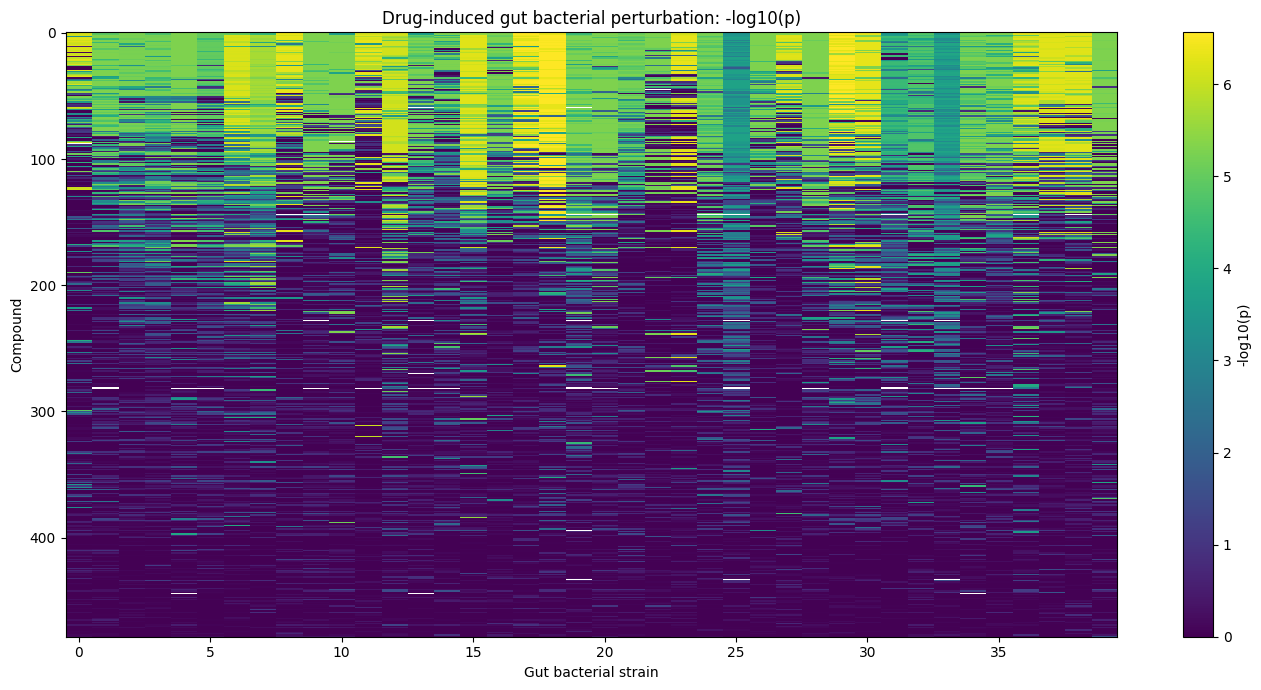

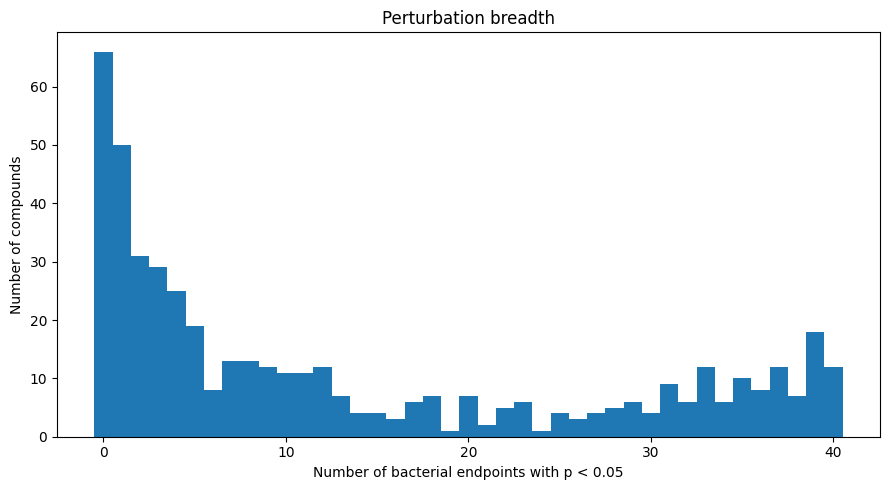

In [5]:
# ============================================================
# 5. Visualize perturbation landscape
# ============================================================

plt.figure(figsize=(14, 7))
plt.imshow(Y_activity, aspect="auto", interpolation="nearest")
plt.xlabel("Gut bacterial strain")
plt.ylabel("Compound")
plt.title("Drug-induced gut bacterial perturbation: -log10(p)")
plt.colorbar(label="-log10(p)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(observed_hits, bins=np.arange(observed_hits.max() + 2) - 0.5)
plt.xlabel("Number of bacterial endpoints with p < 0.05")
plt.ylabel("Number of compounds")
plt.title("Perturbation breadth")
plt.tight_layout()
plt.show()

## 4. Compound-level split

The split is performed at the molecule level. No bacterial endpoint from a compound in the validation/test set is used to train the surrogate.

In [6]:
# ============================================================
# 6. Compound-level train / validation / test split
# ============================================================
from sklearn.model_selection import train_test_split

valid_smiles_mask = df["SMILES"].notna()
indices = np.arange(len(df))[valid_smiles_mask.to_numpy()]

train_idx, test_idx = train_test_split(indices, test_size=0.20, random_state=SEED)
train_idx, val_idx = train_test_split(train_idx, test_size=0.20, random_state=SEED)

print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

Train: 306
Validation: 77
Test: 96


## 5. SMILES → molecular fingerprints

The supplied descriptor block is useful for analysis, but the RL generator will create **new molecules** that do not already have those descriptor values. Therefore the deployable surrogate is based on a representation that can be computed from any generated SMILES: Morgan fingerprints.

In [7]:
# ============================================================
# 7. Morgan fingerprints
# ============================================================
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from tqdm.auto import tqdm

FP_SIZE = 2048
RADIUS = 2

morgan_generator = AllChem.GetMorganGenerator(radius=RADIUS, fpSize=FP_SIZE)

def canonicalize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return None
        return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
    except Exception:
        return None

def fingerprint_bits(smiles):
    mol = Chem.MolFromSmiles(smiles)
    arr = np.zeros(FP_SIZE, dtype=np.uint8)
    if mol is None:
        return arr
    fp = morgan_generator.GetFingerprint(mol)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

work_df = df.loc[valid_smiles_mask].copy().reset_index(drop=True)
work_df["canonical_smiles"] = work_df["SMILES"].apply(canonicalize_smiles)
work_df = work_df[work_df["canonical_smiles"].notna()].reset_index(drop=True)

# Rebuild targets after removing invalid structures.
Y_p_work = work_df[strain_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
Y_activity_work = -np.log10(np.clip(Y_p_work, P_FLOOR, 1.0))
Y_binary_work = (Y_p_work < 0.05).astype(int)

indices = np.arange(len(work_df))
train_idx, test_idx = train_test_split(indices, test_size=0.20, random_state=SEED)
train_idx, val_idx = train_test_split(train_idx, test_size=0.20, random_state=SEED)

X = np.vstack([
    fingerprint_bits(sm)
    for sm in tqdm(work_df["canonical_smiles"], desc="Generating fingerprints")
])

print("Compounds:", len(work_df))
print("X:", X.shape)
print("Y:", Y_activity_work.shape)

Generating fingerprints:   0%|          | 0/479 [00:00<?, ?it/s]

Compounds: 479
X: (479, 2048)
Y: (479, 40)


## 6. Microbiome surrogate

We train an Extra Trees multi-output regressor to predict the continuous perturbation profile. Because the RL generator is optimized against the surrogate, validation performance is reported **before** any RL training.

In [8]:
# ============================================================
# 8. Train endpoint-specific surrogate models
# ============================================================

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, r2_score


class MicrobiomeSurrogate:

    def __init__(
        self,
        n_estimators=400,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
        max_features="sqrt"
    ):

        self.n_estimators = n_estimators
        self.random_state = random_state
        self.n_jobs = n_jobs
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features

        self.models = []
        self.constants = []


    def fit(
        self,
        X,
        Y
    ):

        self.models = []
        self.constants = []

        for j in range(
            Y.shape[1]
        ):

            y = Y[:, j]

            # Only use actually observed responses.
            mask = np.isfinite(y)

            n_obs = int(
                mask.sum()
            )

            if n_obs < 5:

                raise ValueError(
                    f"Endpoint {j} has only "
                    f"{n_obs} observed training values."
                )

            Xj = X[mask]
            yj = y[mask]

            # Endpoint contains no variation.
            if np.nanstd(yj) == 0:

                self.models.append(
                    None
                )

                self.constants.append(
                    float(yj[0])
                )

                continue

            model = ExtraTreesRegressor(

                n_estimators=self.n_estimators,

                random_state=(
                    self.random_state + j
                ),

                n_jobs=self.n_jobs,

                min_samples_leaf=(
                    self.min_samples_leaf
                ),

                max_features=(
                    self.max_features
                )
            )

            model.fit(
                Xj,
                yj
            )

            self.models.append(
                model
            )

            self.constants.append(
                None
            )

        return self


    def predict(
        self,
        X
    ):

        predictions = np.zeros(
            (
                len(X),
                len(self.models)
            ),
            dtype=float
        )

        for j, model in enumerate(
            self.models
        ):

            if model is None:

                predictions[
                    :,
                    j
                ] = self.constants[j]

            else:

                predictions[
                    :,
                    j
                ] = model.predict(X)

        return predictions


# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

surrogate = MicrobiomeSurrogate(
    n_estimators=400,
    random_state=SEED,
    n_jobs=-1,
    min_samples_leaf=2,
    max_features="sqrt"
)

surrogate.fit(
    X[train_idx],
    Y_activity_work[train_idx]
)


# ------------------------------------------------------------
# Predict
# ------------------------------------------------------------

pred_val_activity = surrogate.predict(
    X[val_idx]
)

pred_test_activity = surrogate.predict(
    X[test_idx]
)


# ============================================================
# Masked evaluation
# ============================================================

def masked_metrics(
    y_true,
    y_pred
):

    mae_values = []
    r2_values = []

    for j in range(
        y_true.shape[1]
    ):

        mask = np.isfinite(
            y_true[:, j]
        )

        if mask.sum() == 0:
            continue

        mae_values.append(
            mean_absolute_error(
                y_true[
                    mask,
                    j
                ],
                y_pred[
                    mask,
                    j
                ]
            )
        )

        if (
            mask.sum() >= 2
            and
            np.nanstd(
                y_true[
                    mask,
                    j
                ]
            ) > 0
        ):

            r2_values.append(
                r2_score(
                    y_true[
                        mask,
                        j
                    ],
                    y_pred[
                        mask,
                        j
                    ]
                )
            )

    return (
        float(
            np.mean(
                mae_values
            )
        ),
        float(
            np.mean(
                r2_values
            )
        )
        if r2_values
        else np.nan
    )


val_mae, val_r2 = masked_metrics(
    Y_activity_work[val_idx],
    pred_val_activity
)

test_mae, test_r2 = masked_metrics(
    Y_activity_work[test_idx],
    pred_test_activity
)


print(
    f"Validation MAE: {val_mae:.4f}"
)

print(
    f"Validation R2 : {val_r2:.4f}"
)

print(
    f"Test MAE      : {test_mae:.4f}"
)

print(
    f"Test R2       : {test_r2:.4f}"
)

Validation MAE: 1.2191
Validation R2 : 0.3590
Test MAE      : 1.2142
Test R2       : 0.4311


In [9]:
# ============================================================
# 9. Secondary endpoint-level AUROC
# ============================================================
#
# The surrogate predicts continuous activity:
#
#     Y_activity_work = -log10(p-value)
#
# Higher predicted activity should therefore correspond to
# stronger evidence of bacterial perturbation.
#
# We use the original binary endpoint:
#
#     p < 0.05 -> 1
#     p >= 0.05 -> 0
#
# as the classification target and use the surrogate's
# continuous prediction as the ranking score.
#
# Missing endpoint measurements are excluded from the
# corresponding AUROC calculation.
# ============================================================

from sklearn.metrics import roc_auc_score

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

print(
    "Predicted validation shape:",
    pred_val_activity.shape
)

print(
    "Binary validation shape:",
    Y_binary_work[val_idx].shape
)

print(
    "Number of endpoint names:",
    len(strain_cols)
)


if pred_val_activity.shape[1] != len(strain_cols):

    raise ValueError(
        "Number of surrogate prediction columns does not "
        "match number of strain columns."
    )


if Y_binary_work[val_idx].shape[1] != len(strain_cols):

    raise ValueError(
        "Y_binary_work columns do not match strain_cols."
    )


# ------------------------------------------------------------
# Endpoint-level AUROC
# ------------------------------------------------------------

val_auc = []

Y_val_binary = Y_binary_work[
    val_idx
]

for j, strain in enumerate(
    strain_cols
):

    y_true = np.asarray(
        Y_val_binary[
            :,
            j
        ],
        dtype=float
    )

    y_score = np.asarray(
        pred_val_activity[
            :,
            j
        ],
        dtype=float
    )

    # --------------------------------------------------------
    # Remove missing / non-finite observations.
    # This is important because some compounds do not have
    # a measured response for every bacterial endpoint.
    # --------------------------------------------------------

    mask = (
        np.isfinite(y_true)
        &
        np.isfinite(y_score)
    )

    if mask.sum() < 2:
        continue

    y_true_valid = y_true[
        mask
    ]

    y_score_valid = y_score[
        mask
    ]

    # --------------------------------------------------------
    # AUROC requires both classes to be present.
    # --------------------------------------------------------

    if len(
        np.unique(
            y_true_valid
        )
    ) < 2:

        continue

    auc = roc_auc_score(
        y_true_valid,
        y_score_valid
    )

    val_auc.append(
        {
            "strain": strain,
            "AUROC": auc,
            "n_valid": int(
                mask.sum()
            ),
            "n_active": int(
                np.sum(
                    y_true_valid == 1
                )
            ),
            "n_inactive": int(
                np.sum(
                    y_true_valid == 0
                )
            )
        }
    )


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

auc_df = pd.DataFrame(
    val_auc
)

if auc_df.empty:

    raise ValueError(
        "No bacterial endpoints had enough valid observations "
        "and both activity classes for AUROC calculation."
    )


print(
    "Evaluable endpoints:",
    len(auc_df)
)

print(
    f"Mean endpoint AUROC: "
    f"{auc_df['AUROC'].mean():.4f}"
)

print(
    f"Median endpoint AUROC: "
    f"{auc_df['AUROC'].median():.4f}"
)


display(
    auc_df.sort_values(
        "AUROC",
        ascending=False
    ).reset_index(
        drop=True
    )
)

Predicted validation shape: (77, 40)
Binary validation shape: (77, 40)
Number of endpoint names: 40
Evaluable endpoints: 40
Mean endpoint AUROC: 0.8124
Median endpoint AUROC: 0.8118


,strain,AUROC,n_valid,n_active,n_inactive
0,Escherichia coli ED1a (NT5078),0.908163,77,14,63
1,Ruminococcus gnavus (NT5046),0.894460,77,31,46
2,Fusobacterium nucleatum (NT5025),0.885965,77,20,57
3,Eubacterium eligens (NT5075),0.862903,77,31,46
4,Prevotella copri (NT5019),0.861152,77,28,49
5,Dorea formicigenerans (NT5076),0.860058,77,28,49
6,Clostridium bolteae (NT5026),0.859277,77,24,53
7,Blautia obeum (NT5069),0.858401,77,36,41
8,Clostridium perfringens (NT5032),0.854651,77,34,43
9,Akkermansia muciniphila (NT5021),0.852608,77,14,63


In [10]:
# ============================================================
# 10. Surrogate prediction helper for arbitrary SMILES
# ============================================================

def predict_activity(smiles_list):
    canonical = [canonicalize_smiles(s) for s in smiles_list]
    if any(s is None for s in canonical):
        raise ValueError("At least one generated SMILES is invalid.")
    X_new = np.vstack([fingerprint_bits(s) for s in canonical])
    return surrogate.predict(X_new)

# Sanity check on a held-out molecule.
example_smiles = work_df.iloc[test_idx[0]]["canonical_smiles"]
example_pred = predict_activity([example_smiles])[0]
print("Example molecule:", example_smiles)
print("Predicted activity vector shape:", example_pred.shape)
print("Top predicted affected strains:")
for k in np.argsort(example_pred)[::-1][:5]:
    print(f"  {strain_cols[k]} -> {example_pred[k]:.3f}")

Example molecule: CN(C)CCn1nnnc1SCC1=C(C(=O)O)N2C(=O)C(NC(=O)Cc3csc(N)n3)C2SC1.Cl
Predicted activity vector shape: (40,)
Top predicted affected strains:
  Collinsella aerofaciens (NT5073) -> 5.577
  Clostridium perfringens (NT5032) -> 5.545
  Streptococcus salivarius (NT5038) -> 5.540
  Streptococcus parasanguinis (NT5072) -> 5.348
  Clostridium saccharolyticum (NT5037) -> 5.222


## 7. Define multi-objective panels

There is no unique biological target panel in the uploaded file. The default below is therefore an **analytical demonstration**:

- target panel = upper quartile of strain-level hit prevalence,
- preservation panel = lower quartile.

Replace these masks with biologically justified taxa or functional groups for a real study.

In [11]:
# ============================================================
# 11. Target and preservation panels
# ============================================================

strain_hit_rate_train = Y_binary_work[train_idx].mean(axis=0)

TARGET_Q = 0.75
PRESERVE_Q = 0.25

target_indices = np.where(
    strain_hit_rate_train >= np.quantile(strain_hit_rate_train, TARGET_Q)
)[0]

preserve_indices = np.where(
    strain_hit_rate_train <= np.quantile(strain_hit_rate_train, PRESERVE_Q)
)[0]

print("Target panel:")
for i in target_indices:
    print(" ", strain_cols[i])

print("\nPreservation panel:")
for i in preserve_indices:
    print(" ", strain_cols[i])

Target panel:
  Bacteroides uniformis (NT5002)
  Bacteroides vulgatus (NT5001)
  Blautia obeum (NT5069)
  Clostridium perfringens (NT5032)
  Coprococcus comes (NT5048)
  Eubacterium eligens (NT5075)
  Eubacterium rectale (NT5009)
  Prevotella copri (NT5019)
  Roseburia intestinalis (NT5011)
  Ruminococcus torques (NT5047)

Preservation panel:
  Akkermansia muciniphila (NT5021)
  Bacteroides xylanisolvens (NT5064)
  Bilophila wadsworthia (NT5036)
  Clostridium bolteae (NT5026)
  Clostridium difficile (NT5083)
  Escherichia coli ED1a (NT5078)
  Escherichia coli IAI1 (NT5077)
  Fusobacterium nucleatum (NT5025)
  Lactobacillus paracasei (NT5042)
  Veillonella parvula (NT5017)


## 8. Molecule evaluator

The RL agent gets a smooth scalar reward, but we keep the objectives separately so the final library can be inspected with a Pareto analysis.

In [12]:
# ============================================================
# 12. Molecular objective evaluator
# ============================================================
from rdkit.Chem import Descriptors, Crippen, QED, Lipinski, rdMolDescriptors


def evaluate_candidate(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None

    canonical = Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
    activity = predict_activity([canonical])[0]

    target_perturbation = float(activity[target_indices].mean())
    preservation = float(np.clip(1.0 - activity[preserve_indices].mean() / max(activity.max(), 1.0), 0.0, 1.0))

    # Scale target/preservation into [0,1] for reward stability.
    target_score = float(1.0 - np.exp(-target_perturbation))

    unwanted = float(activity[preserve_indices].mean())
    preservation = float(np.exp(-unwanted))

    raw_selectivity = target_score - (1.0 - preservation)
    selectivity = float(np.clip(0.5 + 0.5 * raw_selectivity, 0.0, 1.0))

    qed = float(QED.qed(mol))
    mw = float(Descriptors.MolWt(mol))
    logp = float(Crippen.MolLogP(mol))
    tpsa = float(rdMolDescriptors.CalcTPSA(mol))
    hbd = int(Lipinski.NumHDonors(mol))
    hba = int(Lipinski.NumHAcceptors(mol))

    # Broad chemical sanity score; deliberately not a hard medicinal-chemistry claim.
    size_score = float(np.exp(-max(0.0, mw - 650.0) / 150.0))
    logp_score = float(np.exp(-max(0.0, logp - 5.0) / 2.0))
    desirability = 0.6 * qed + 0.2 * size_score + 0.2 * logp_score

    reward = (
        0.40 * target_score
        + 0.25 * preservation
        + 0.20 * selectivity
        + 0.15 * desirability
    )

    return {
        "SMILES": canonical,
        "target_perturbation": target_perturbation,
        "target_score": target_score,
        "preservation": preservation,
        "selectivity": selectivity,
        "QED": qed,
        "MW": mw,
        "LogP": logp,
        "TPSA": tpsa,
        "HBD": hbd,
        "HBA": hba,
        "reward": float(reward),
        "activity_vector": activity,
    }

# Sanity check.
res = evaluate_candidate(example_smiles)
for k, v in res.items():
    if k != "activity_vector":
        print(f"{k:22s}: {v}")

SMILES                : CN(C)CCn1nnnc1SCC1=C(C(=O)O)N2C(=O)C(NC(=O)Cc3csc(N)n3)C2SC1.Cl
target_perturbation   : 4.12171728806342
target_score          : 0.9837833581293305
preservation          : 0.09612155178875666
selectivity           : 0.5399524549590435
QED                   : 0.2570844764699827
MW                    : 562.1030000000002
LogP                  : -0.23139999999999683
TPSA                  : 172.45999999999998
HBD                   : 3
HBA                   : 12
reward                : 0.6086718250730285


## 9. Character-level GRU policy

The generator is first fit to the uploaded compound set with teacher forcing. This gives REINFORCE a sensible starting policy instead of sampling random chemical strings.

In [13]:
# ============================================================
# 13. Build character vocabulary
# ============================================================

smiles_corpus = work_df["canonical_smiles"].tolist()

SPECIAL = ["<PAD>", "<SOS>", "<EOS>"]
chars = sorted(set("".join(smiles_corpus)))
it2token = SPECIAL + chars
token2id = {tok: i for i, tok in enumerate(it2token)}

PAD = token2id["<PAD>"]
SOS = token2id["<SOS>"]
EOS = token2id["<EOS>"]
VOCAB_SIZE = len(it2token)
MAX_LEN = min(120, max(len(s) for s in smiles_corpus) + 1)

print("Vocabulary:", VOCAB_SIZE)
print("Max length:", MAX_LEN)


def encode_smiles(smiles, max_len=MAX_LEN):
    ids = [SOS] + [token2id[c] for c in smiles] + [EOS]
    ids = ids[:max_len]
    if len(ids) < max_len:
        ids += [PAD] * (max_len - len(ids))
    return ids

X_tokens = torch.tensor(
    np.array([encode_smiles(s) for s in smiles_corpus]),
    dtype=torch.long
)

print("Token tensor:", X_tokens.shape)

Vocabulary: 40
Max length: 120
Token tensor: torch.Size([479, 120])


In [14]:
# ============================================================
# 14. GRU policy network
# ============================================================

class SmilesGRUPolicy(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden_dim=256, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.gru = nn.GRU(
            emb_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
        )
        self.decoder = nn.Linear(hidden_dim, vocab_size)

    def forward(self, tokens, hidden=None):
        x = self.embedding(tokens)
        out, hidden = self.gru(x, hidden)
        logits = self.decoder(out)
        return logits, hidden

policy = SmilesGRUPolicy(VOCAB_SIZE).to(device)
optimizer = torch.optim.Adam(policy.parameters(), lr=2e-3)

print(policy)

SmilesGRUPolicy(
  (embedding): Embedding(40, 128, padding_idx=0)
  (gru): GRU(128, 256, num_layers=2, batch_first=True)
  (decoder): Linear(in_features=256, out_features=40, bias=True)
)


In [15]:
# ============================================================
# 15. Teacher-forced pretraining
# ============================================================

loader = torch.utils.data.DataLoader(
    X_tokens,
    batch_size=32,
    shuffle=True,
)

PRETRAIN_EPOCHS = 30

policy.train()
for epoch in range(PRETRAIN_EPOCHS):
    running = 0.0
    n = 0

    for batch in loader:
        batch = batch.to(device)
        inp = batch[:, :-1]
        target = batch[:, 1:]

        logits, _ = policy(inp)
        loss = F.cross_entropy(
            logits.reshape(-1, VOCAB_SIZE),
            target.reshape(-1),
            ignore_index=PAD,
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
        optimizer.step()

        running += float(loss.item()) * len(batch)
        n += len(batch)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | loss={running/n:.4f}")

Epoch 05 | loss=1.2546
Epoch 10 | loss=0.9358
Epoch 15 | loss=0.6965
Epoch 20 | loss=0.5086
Epoch 25 | loss=0.3725
Epoch 30 | loss=0.2802


In [16]:
# ============================================================
# 16. Differentiable SMILES sampler for REINFORCE
# ============================================================

from torch.distributions import Categorical


def sample_smiles(
    policy,
    max_len=MAX_LEN,
    temperature=0.9
):

    # Make absolutely sure gradients are enabled.
    policy.train()

    tokens = [
        SOS
    ]

    log_prob_terms = []

    hidden = None

    terminated = False

    for _ in range(
        max_len - 1
    ):

        # ----------------------------------------------------
        # Current token
        # ----------------------------------------------------

        token = torch.tensor(
            [[tokens[-1]]],
            dtype=torch.long,
            device=device
        )

        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        logits, hidden = policy(
            token,
            hidden
        )

        logits = logits[
            0,
            -1,
            :
        ]

        # ----------------------------------------------------
        # Temperature
        # ----------------------------------------------------

        logits = (
            logits
            /
            max(
                float(temperature),
                1e-4
            )
        )

        # ----------------------------------------------------
        # Prevent meaningless tokens
        # ----------------------------------------------------

        logits = logits.clone()

        logits[
            PAD
        ] = -1e9

        logits[
            SOS
        ] = -1e9

        # ----------------------------------------------------
        # Probability distribution
        # ----------------------------------------------------

        log_probs = F.log_softmax(
            logits,
            dim=-1
        )

        probs = torch.exp(
            log_probs
        )

        # ----------------------------------------------------
        # Sample action
        # ----------------------------------------------------

        action = torch.multinomial(
            probs,
            num_samples=1
        )

        action_id = int(
            action.item()
        )

        # ----------------------------------------------------
        # IMPORTANT:
        # take the log probability from the ORIGINAL
        # differentiable tensor.
        # ----------------------------------------------------

        action_log_prob = log_probs[
            action_id
        ]

        log_prob_terms.append(
            action_log_prob
        )

        # ----------------------------------------------------
        # EOS
        # ----------------------------------------------------

        if action_id == EOS:

            terminated = True

            break

        # ----------------------------------------------------
        # Continue generation
        # ----------------------------------------------------

        tokens.append(
            action_id
        )

    # --------------------------------------------------------
    # Sequence log probability
    # --------------------------------------------------------

    if len(
        log_prob_terms
    ) == 0:

        # This should almost never occur, but return a tensor
        # connected to the policy rather than torch.tensor(0).
        sequence_log_prob = (
            next(
                policy.parameters()
            ).sum()
            * 0.0
        )

        return (
            "",
            sequence_log_prob,
            terminated
        )

    sequence_log_prob = torch.stack(
        log_prob_terms
    ).sum()

    # --------------------------------------------------------
    # Decode
    # --------------------------------------------------------

    smiles = "".join(
        it2token[i]
        for i in tokens
        if i not in [
            SOS,
            EOS,
            PAD
        ]
    )

    return (
        smiles,
        sequence_log_prob,
        terminated
    )

## 10. REINFORCE fine-tuning

Reward is evaluated only for valid molecules. The mean reward of a batch is used as a baseline to reduce variance. A novelty bonus prevents the policy from collapsing entirely onto the original 479 molecules.

In [17]:
# ============================================================
# 17. REINFORCE fine-tuning until a fixed number of molecules
# ============================================================

original_smiles = set(
    work_df[
        "canonical_smiles"
    ]
    .dropna()
    .astype(str)
)

# ------------------------------------------------------------
# Main controls
# ------------------------------------------------------------

N_GENERATED = 100        # Change to 500, 1000, etc.
BATCH_SIZE = 24
TEMPERATURE = 0.9
RL_LR = 5e-4

INVALID_REWARD = -0.50
TRUNCATED_PENALTY = 0.10
NOVELTY_BONUS = 0.05

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

rl_optimizer = torch.optim.Adam(
    policy.parameters(),
    lr=RL_LR
)

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

reward_history = []
valid_history = []
invalid_history = []
truncated_history = []

# ------------------------------------------------------------
# Generated-molecule storage
# ------------------------------------------------------------

unique_generated = set()
generated_records = []

policy.train()

update_step = 0

while len(
    unique_generated
) < N_GENERATED:

    batch_log_probs = []
    batch_rewards = []

    valid_count = 0
    invalid_count = 0
    truncated_count = 0

    # ========================================================
    # Generate one batch of trajectories
    # ========================================================

    for _ in range(
        BATCH_SIZE
    ):

        # ----------------------------------------------------
        # Sample molecule
        # ----------------------------------------------------

        smiles, log_prob, terminated = (
            sample_smiles(
                policy,
                max_len=MAX_LEN,
                temperature=TEMPERATURE
            )
        )

        # ----------------------------------------------------
        # Make sure REINFORCE graph is intact
        # ----------------------------------------------------

        if not log_prob.requires_grad:

            raise RuntimeError(
                "sample_smiles() returned a detached "
                "log-probability. "
                "Check that sample_smiles() does not use "
                "@torch.no_grad() and does not detach log_prob."
            )

        # ----------------------------------------------------
        # Empty generation
        # ----------------------------------------------------

        if not smiles:

            batch_log_probs.append(
                log_prob
            )

            batch_rewards.append(
                INVALID_REWARD
            )

            invalid_count += 1

            continue

        # ----------------------------------------------------
        # Track sequences that reached MAX_LEN
        # ----------------------------------------------------

        if not terminated:

            truncated_count += 1

        # ----------------------------------------------------
        # Evaluate molecule
        # ----------------------------------------------------

        result = evaluate_candidate(
            smiles
        )

        # ----------------------------------------------------
        # Invalid molecular structure
        # ----------------------------------------------------

        if result is None:

            batch_log_probs.append(
                log_prob
            )

            batch_rewards.append(
                INVALID_REWARD
            )

            invalid_count += 1

            continue

        # ====================================================
        # Base reward
        # ====================================================

        reward = float(
            result.get(
                "reward",
                0.0
            )
        )

        # ----------------------------------------------------
        # Penalize truncated sequence
        # ----------------------------------------------------

        if not terminated:

            reward -= (
                TRUNCATED_PENALTY
            )

        # ----------------------------------------------------
        # Get canonical SMILES safely
        # ----------------------------------------------------
        #
        # evaluate_candidate() may either return "SMILES"
        # or may expect us to use the generated SMILES.
        #
        # ----------------------------------------------------

        candidate_smiles = result.get(
            "SMILES",
            smiles
        )

        # ----------------------------------------------------
        # Canonicalize once more to ensure consistent
        # duplicate checking.
        # ----------------------------------------------------

        try:

            mol = Chem.MolFromSmiles(
                candidate_smiles
            )

            if mol is None:

                batch_log_probs.append(
                    log_prob
                )

                batch_rewards.append(
                    INVALID_REWARD
                )

                invalid_count += 1

                continue

            candidate_smiles = (
                Chem.MolToSmiles(
                    mol,
                    canonical=True,
                    isomericSmiles=True
                )
            )

        except Exception:

            batch_log_probs.append(
                log_prob
            )

            batch_rewards.append(
                INVALID_REWARD
            )

            invalid_count += 1

            continue

        # ====================================================
        # Novelty bonus
        # ====================================================

        is_novel = (
            candidate_smiles
            not in
            original_smiles
        )

        if is_novel:

            reward += (
                NOVELTY_BONUS
            )

        # ====================================================
        # Store trajectory
        # ====================================================

        batch_log_probs.append(
            log_prob
        )

        batch_rewards.append(
            reward
        )

        valid_count += 1

        # ====================================================
        # Store unique generated molecule
        # ====================================================

        if (
            candidate_smiles
            not in
            unique_generated
        ):

            unique_generated.add(
                candidate_smiles
            )

            # ------------------------------------------------
            # Build record using safe .get()
            # ------------------------------------------------
            #
            # This avoids the previous KeyError caused by:
            #
            #     result["overall_perturbation"]
            #
            # ------------------------------------------------

            record = {
                "SMILES":
                    candidate_smiles,

                "reward":
                    reward,

                "target_perturbation":
                    result.get(
                        "target_perturbation",
                        np.nan
                    ),

                "preservation":
                    result.get(
                        "preservation",
                        np.nan
                    ),

                "selectivity":
                    result.get(
                        "selectivity",
                        np.nan
                    ),

                "overall_perturbation":
                    result.get(
                        "overall_perturbation",
                        result.get(
                            "overall_effect",
                            np.nan
                        )
                    ),

                "QED":
                    result.get(
                        "QED",
                        np.nan
                    ),

                "MW":
                    result.get(
                        "MW",
                        np.nan
                    ),

                "LogP":
                    result.get(
                        "LogP",
                        np.nan
                    ),

                "TPSA":
                    result.get(
                        "TPSA",
                        np.nan
                    ),

                "HBD":
                    result.get(
                        "HBD",
                        np.nan
                    ),

                "HBA":
                    result.get(
                        "HBA",
                        np.nan
                    ),

                "novel":
                    is_novel,

                "terminated":
                    terminated
            }

            generated_records.append(
                record
            )

        # ----------------------------------------------------
        # Stop once enough UNIQUE valid molecules exist
        # ----------------------------------------------------

        if (
            len(unique_generated)
            >=
            N_GENERATED
        ):

            break

    # ========================================================
    # REINFORCE update
    # ========================================================

    if not batch_rewards:

        continue

    rewards = torch.tensor(
        batch_rewards,
        dtype=torch.float32,
        device=device
    )

    # --------------------------------------------------------
    # Batch baseline
    # --------------------------------------------------------

    baseline = (
        rewards.mean()
        .detach()
    )

    advantages = (
        rewards
        -
        baseline
    )

    # --------------------------------------------------------
    # Normalize advantages
    # --------------------------------------------------------

    if len(
        advantages
    ) > 1:

        advantage_std = (
            advantages.std(
                unbiased=False
            )
        )

        if (
            torch.isfinite(
                advantage_std
            )
            and
            advantage_std > 1e-8
        ):

            advantages = (
                advantages
                /
                advantage_std
            )

    # --------------------------------------------------------
    # Stack differentiable log-probabilities
    # --------------------------------------------------------

    log_probs = torch.stack(
        batch_log_probs
    )

    if not log_probs.requires_grad:

        raise RuntimeError(
            "The stacked log-probabilities are detached. "
            "REINFORCE cannot update the policy."
        )

    # --------------------------------------------------------
    # REINFORCE loss
    # --------------------------------------------------------

    loss = -(
        advantages.detach()
        *
        log_probs
    ).mean()

    # --------------------------------------------------------
    # Policy update
    # --------------------------------------------------------

    rl_optimizer.zero_grad(
        set_to_none=True
    )

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        policy.parameters(),
        max_norm=1.0
    )

    rl_optimizer.step()

    update_step += 1

    # ========================================================
    # Diagnostics
    # ========================================================

    mean_reward = float(
        rewards.mean().item()
    )

    valid_fraction = (
        valid_count
        /
        BATCH_SIZE
    )

    invalid_fraction = (
        invalid_count
        /
        BATCH_SIZE
    )

    truncated_fraction = (
        truncated_count
        /
        BATCH_SIZE
    )

    reward_history.append(
        mean_reward
    )

    valid_history.append(
        valid_fraction
    )

    invalid_history.append(
        invalid_fraction
    )

    truncated_history.append(
        truncated_fraction
    )

    # ========================================================
    # Progress report
    # ========================================================

    if (
        update_step % 10 == 0
        or
        len(unique_generated)
        >=
        N_GENERATED
    ):

        print(
            f"Update {update_step:03d} | "
            f"generated={len(unique_generated)}/{N_GENERATED} | "
            f"reward={mean_reward:.4f} | "
            f"valid={valid_fraction:.2%} | "
            f"invalid={invalid_fraction:.2%} | "
            f"truncated={truncated_fraction:.2%}"
        )


# ============================================================
# 18. Final generated library
# ============================================================

generated_df = pd.DataFrame(
    generated_records
)

if not generated_df.empty:

    generated_df = (
        generated_df
        .drop_duplicates(
            subset=["SMILES"]
        )
        .reset_index(
            drop=True
        )
    )

print(
    "\n============================================================"
)

print(
    "REINFORCE GENERATION COMPLETE"
)

print(
    "============================================================"
)

print(
    "Requested unique molecules:",
    N_GENERATED
)

print(
    "Generated unique molecules:",
    len(generated_df)
)

print(
    "Policy updates:",
    update_step
)

print(
    "============================================================"
)

display(
    generated_df.head(20)
)

[12:39:59] SMILES Parse Error: extra open parentheses while parsing: CC12CCC3c4c4c(O)c(c(C=NN5CCN(CC)CC4)c(O)c4c(O)c(c5c(c4c3C2=O)NC(=O)C(C)=CC=CC(C)C(O)C(C)C(O)C(C)C(O)C(C)C(OC(C)=O)C1C
[12:39:59] SMILES Parse Error: check for mistakes around position 18:
[12:39:59] CC12CCC3c4c4c(O)c(c(C=NN5CCN(CC)CC4)c(O)c
[12:39:59] ~~~~~~~~~~~~~~~~~^
[12:39:59] SMILES Parse Error: extra open parentheses while parsing: CC12CCC3c4c4c(O)c(c(C=NN5CCN(CC)CC4)c(O)c4c(O)c(c5c(c4c3C2=O)NC(=O)C(C)=CC=CC(C)C(O)C(C)C(O)C(C)C(O)C(C)C(OC(C)=O)C1C
[12:39:59] SMILES Parse Error: check for mistakes around position 48:
[12:39:59] N(CC)CC4)c(O)c4c(O)c(c5c(c4c3C2=O)NC(=O)C
[12:39:59] ~~~~~~~~~~~~~~~~~~~~^
[12:39:59] SMILES Parse Error: Failed parsing SMILES 'CC12CCC3c4c4c(O)c(c(C=NN5CCN(CC)CC4)c(O)c4c(O)c(c5c(c4c3C2=O)NC(=O)C(C)=CC=CC(C)C(O)C(C)C(O)C(C)C(O)C(C)C(OC(C)=O)C1C' for input: 'CC12CCC3c4c4c(O)c(c(C=NN5CCN(CC)CC4)c(O)c4c(O)c(c5c(c4c3C2=O)NC(=O)C(C)=CC=CC(C)C(O)C(C)C(O)C(C)C(O)C(C)C(OC(C)=O)C1C'
[12:40:02] SM

Update 010 | generated=96/100 | reward=0.0527 | valid=45.83% | invalid=54.17% | truncated=0.00%


[12:47:10] Can't kekulize mol.  Unkekulized atoms: 2 3 4
[12:47:10] Can't kekulize mol.  Unkekulized atoms: 2 3 4
[12:47:11] SMILES Parse Error: extra open parentheses while parsing: NC(C(=O)NC1C(=O)NCC1C(=O)NC(CC(C)Cl)Cl
[12:47:11] SMILES Parse Error: check for mistakes around position 3:
[12:47:11] NC(C(=O)NC1C(=O)NCC1C(=O)NC(CC(C)Cl)Cl
[12:47:11] ~~^
[12:47:11] SMILES Parse Error: Failed parsing SMILES 'NC(C(=O)NC1C(=O)NCC1C(=O)NC(CC(C)Cl)Cl' for input: 'NC(C(=O)NC1C(=O)NCC1C(=O)NC(CC(C)Cl)Cl'
[12:47:11] SMILES Parse Error: extra close parentheses while parsing: NC(=O)C1CCC2C3CCC4=CCCCC(C)C1)CC1
[12:47:11] SMILES Parse Error: check for mistakes around position 30:
[12:47:11] CC2C3CCC4=CCCCC(C)C1)CC1
[12:47:11] ~~~~~~~~~~~~~~~~~~~~^
[12:47:11] SMILES Parse Error: Failed parsing SMILES 'NC(=O)C1CCC2C3CCC4=CCCCC(C)C1)CC1' for input: 'NC(=O)C1CCC2C3CCC4=CCCCC(C)C1)CC1'
[12:47:15] SMILES Parse Error: extra close parentheses while parsing: O=C1c2ccccc2Cc2ccccc2)cc1
[12:47:15] SMILES Parse

Update 011 | generated=100/100 | reward=-0.0304 | valid=20.83% | invalid=33.33% | truncated=0.00%

REINFORCE GENERATION COMPLETE
Requested unique molecules: 100
Generated unique molecules: 100
Policy updates: 11


,SMILES,reward,target_perturbation,preservation,selectivity,overall_perturbation,QED,MW,LogP,TPSA,HBD,HBA,novel,terminated
0,Cl.O=[N+]([O-])c1nccn1CC(O)NCCO,0.695015,1.432550,0.495449,0.628375,NaN,0.343975,252.658,-0.88660,113.45,3,6,True,True
1,NC1CONC1=O,0.618449,0.885768,0.656907,0.622255,NaN,0.385893,102.093,-1.62490,64.35,2,3,False,True
2,CN1CCN(CCCCCCC=C2c3ccccc3Sc3ccccc3Sc3ccccc32)C...,0.673259,1.312941,0.578516,0.654744,NaN,0.218704,537.238,8.35380,6.48,0,4,True,True
3,CCC(CC(F)(F)F)NC(=O)c1ccc(NS(C)(=O)=O)cc1,0.694552,1.403989,0.377278,0.565831,NaN,0.836807,338.351,2.51890,75.27,2,3,True,True
4,COC1=CC=C(NS(=O)(=O)c2ccc(N)cc2)N=C(c2nccs2)C=C1,0.627891,0.587246,0.648412,0.546278,NaN,0.765278,388.474,2.43440,106.67,2,7,True,True
5,ClC1=CC=C(CCC(Cn2ccnc2)OCc2ccccc2)CC1.O=C(O)C=...,0.797345,2.287537,0.552878,0.725681,NaN,0.495508,458.942,4.80340,101.65,2,4,True,True
6,CCCCCCCCCCCN(Cc1ccc(O)c(O)c1)C(=O)OC(C)(C)C,0.680870,1.469842,0.491177,0.630608,NaN,0.319818,393.568,6.36570,70.00,2,4,True,True
7,NC(=O)OCC1=C(C(=O)[O-])N2C(=O)C(C(=O)[O-])C2SC...,0.672753,2.991172,0.172822,0.561297,NaN,0.304222,323.238,-6.62910,152.89,1,8,True,True
8,CCC(CCOC(=O)C1(C2CCCCC2)CCCCC1)NOC(C)=O.Cl,0.719321,1.330391,0.566513,0.651070,NaN,0.480313,389.964,4.71860,64.63,1,5,True,True
9,CCC1OC(=O)C(C)C(OC2CC(CO)(OC)C(O)C(C)O2)C(C)C(...,0.643856,3.597851,0.099104,0.535861,NaN,0.224064,691.856,0.76100,193.91,5,14,True,True


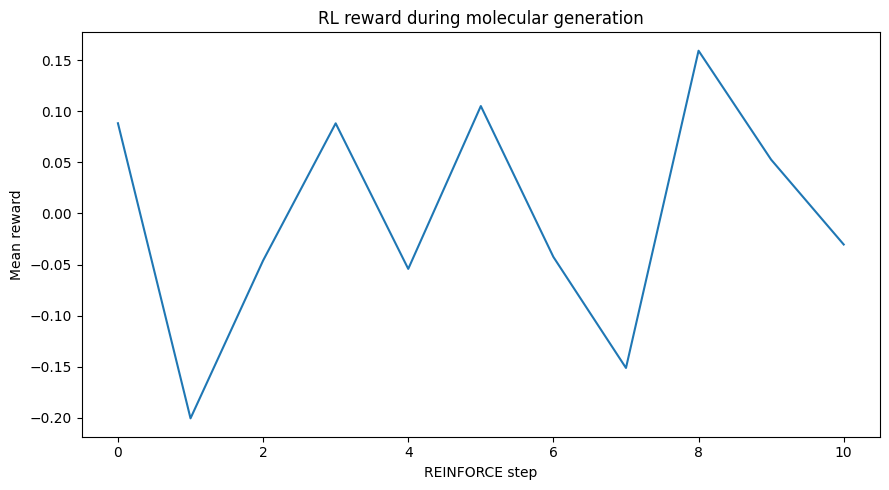

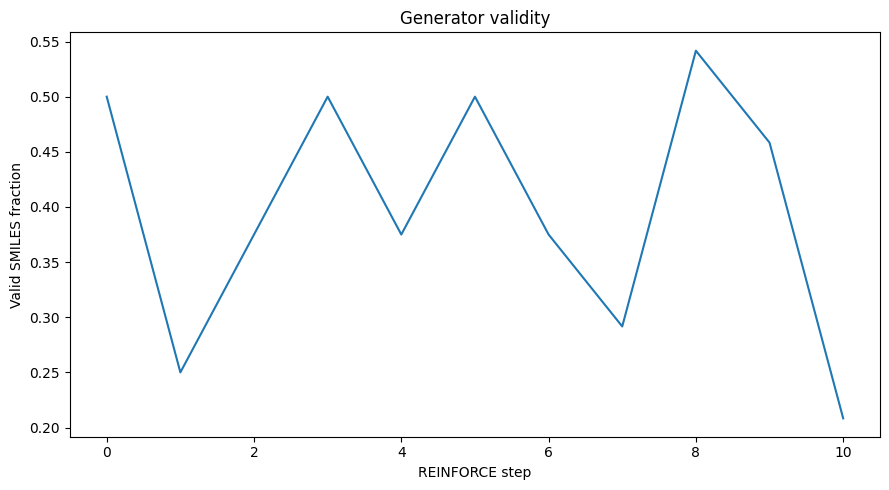

In [18]:
# ============================================================
# 18. RL learning curves
# ============================================================

plt.figure(figsize=(9, 5))
plt.plot(reward_history)
plt.xlabel("REINFORCE step")
plt.ylabel("Mean reward")
plt.title("RL reward during molecular generation")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(valid_history)
plt.xlabel("REINFORCE step")
plt.ylabel("Valid SMILES fraction")
plt.title("Generator validity")
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# 20. Build and finalize results table
# ============================================================
#
# Re-evaluate every clean generated molecule using the current
# microbiome surrogate so that all reported objectives are
# internally consistent.
#
# Outputs:
#   TargetPerturbation
#   TargetScore
#   Preservation
#   Selectivity
#   OverallPerturbation
#   QED
#   MW
#   LogP
#   TPSA
#   HBD
#   HBA
#   Reward
#   Novel
#   Terminated
#
# ============================================================

from rdkit import Chem


# ------------------------------------------------------------
# 1. Check that generated molecules exist
# ------------------------------------------------------------

if (
    "generated_df" not in globals()
    or
    generated_df.empty
):

    raise RuntimeError(
        "generated_df is empty. "
        "Run the REINFORCE generation cell first."
    )


# ------------------------------------------------------------
# 2. Helper: canonicalize a SMILES
# ------------------------------------------------------------

def canonicalize_smiles(
    smiles
):

    try:

        mol = Chem.MolFromSmiles(
            str(smiles)
        )

        if mol is None:
            return None

        return Chem.MolToSmiles(
            mol,
            canonical=True,
            isomericSmiles=True
        )

    except Exception:

        return None


# ------------------------------------------------------------
# 3. Helper: primary candidate filter
# ------------------------------------------------------------
#
# Keep the final candidate set to single-component,
# chemically parseable molecules with at least 5 heavy atoms.
#
# This removes things such as:
#
#   molecule.Cl
#   molecule.[Na+]
#   disconnected fragments
#
# from the primary candidate table.
# ------------------------------------------------------------

def is_clean_candidate(
    smiles
):

    if not isinstance(
        smiles,
        str
    ):

        return False

    smiles = smiles.strip()

    if not smiles:

        return False

    # Reject disconnected structures / salts.
    if "." in smiles:

        return False

    try:

        mol = Chem.MolFromSmiles(
            smiles
        )

        if mol is None:

            return False

        if (
            len(
                Chem.GetMolFrags(
                    mol
                )
            )
            != 1
        ):

            return False

        if (
            mol.GetNumHeavyAtoms()
            < 5
        ):

            return False

        return True

    except Exception:

        return False


# ------------------------------------------------------------
# 4. Prepare raw generated molecules
# ------------------------------------------------------------

raw_df = generated_df.copy()

raw_df[
    "SMILES"
] = (
    raw_df[
        "SMILES"
    ]
    .apply(
        canonicalize_smiles
    )
)

raw_df = raw_df.dropna(
    subset=["SMILES"]
)

raw_df[
    "CleanStructure"
] = raw_df[
    "SMILES"
].apply(
    is_clean_candidate
)

clean_df = (
    raw_df[
        raw_df[
            "CleanStructure"
        ]
    ]
    .drop_duplicates(
        subset=["SMILES"]
    )
    .reset_index(
        drop=True
    )
)


print(
    "Raw generated molecules:",
    len(raw_df)
)

print(
    "Clean unique molecules:",
    len(clean_df)
)


if clean_df.empty:

    raise RuntimeError(
        "No clean unique molecules remain after "
        "structure filtering."
    )


# ============================================================
# 5. Re-evaluate the final clean molecules
# ============================================================
#
# This is the important part:
#
# Instead of trusting possibly incomplete fields carried over
# from the generation loop, recompute the microbiome objectives
# from the final canonical SMILES.
#
# ============================================================

final_records = []

for _, row in clean_df.iterrows():

    smiles = row[
        "SMILES"
    ]

    result = evaluate_candidate(
        smiles
    )

    if result is None:

        continue


    # --------------------------------------------------------
    # Predicted whole-panel perturbation
    # --------------------------------------------------------
    #
    # Prefer the explicitly returned value.
    #
    # Otherwise derive it directly from the 40-dimensional
    # surrogate response.
    # --------------------------------------------------------

    probabilities = result.get(
        "microbiome_probabilities",
        None
    )

    if probabilities is not None:

        overall_perturbation = float(
            np.nanmean(
                probabilities
            )
        )

    else:

        overall_perturbation = result.get(
            "overall_perturbation",
            np.nan
        )


    # --------------------------------------------------------
    # Target score
    # --------------------------------------------------------
    #
    # TargetScore is kept as an alias for the current
    # target-panel perturbation objective.
    # --------------------------------------------------------

    target_perturbation = result.get(
        "target_perturbation",
        np.nan
    )

    target_score = result.get(
        "target_score",
        target_perturbation
    )


    # --------------------------------------------------------
    # Preserve original generation metadata
    # --------------------------------------------------------

    original_reward = row.get(
        "reward",
        result.get(
            "reward",
            np.nan
        )
    )

    is_novel = row.get(
        "novel",
        smiles not in original_smiles
    )

    terminated = row.get(
        "terminated",
        True
    )


    final_records.append(
        {
            "SMILES":
                smiles,

            "TargetPerturbation":
                float(
                    target_perturbation
                ),

            "TargetScore":
                float(
                    target_score
                ),

            "Preservation":
                float(
                    result.get(
                        "preservation",
                        np.nan
                    )
                ),

            "Selectivity":
                float(
                    result.get(
                        "selectivity",
                        np.nan
                    )
                ),

            "OverallPerturbation":
                overall_perturbation,

            "QED":
                float(
                    result.get(
                        "QED",
                        np.nan
                    )
                ),

            "MW":
                float(
                    result.get(
                        "MW",
                        np.nan
                    )
                ),

            "LogP":
                float(
                    result.get(
                        "LogP",
                        np.nan
                    )
                ),

            "TPSA":
                float(
                    result.get(
                        "TPSA",
                        np.nan
                    )
                ),

            "HBD":
                float(
                    result.get(
                        "HBD",
                        np.nan
                    )
                ),

            "HBA":
                float(
                    result.get(
                        "HBA",
                        np.nan
                    )
                ),

            "Reward":
                float(
                    original_reward
                ),

            "Novel":
                bool(
                    is_novel
                ),

            "Terminated":
                bool(
                    terminated
                )
        }
    )


# ============================================================
# 6. Final results table
# ============================================================

results_df = pd.DataFrame(
    final_records
)


if results_df.empty:

    raise RuntimeError(
        "No valid candidate evaluations were obtained."
    )


# ------------------------------------------------------------
# Remove duplicate SMILES again defensively
# ------------------------------------------------------------

results_df = (
    results_df
    .drop_duplicates(
        subset=["SMILES"]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 7. Check for missing objective values
# ============================================================

objective_columns = [
    "TargetPerturbation",
    "TargetScore",
    "Preservation",
    "Selectivity",
    "OverallPerturbation",
    "QED",
    "MW",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "Reward"
]


print(
    "\nMissing values in final results:"
)

missing_summary = (
    results_df[
        objective_columns
    ]
    .isna()
    .sum()
)

display(
    missing_summary[
        missing_summary > 0
    ]
)


# ============================================================
# 8. Rank candidates
# ============================================================

results_df = (
    results_df
    .sort_values(
        "Reward",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 9. Final summary
# ============================================================

print(
    "\n============================================================"
)

print(
    "FINAL CLEAN GENERATED CANDIDATES"
)

print(
    "============================================================"
)

print(
    "Number of candidates:",
    len(results_df)
)

print(
    "Novel candidates:",
    int(
        results_df["Novel"].sum()
    )
)

print(
    "Novel fraction:",
    f"{results_df['Novel'].mean():.2%}"
)

print(
    "Properly terminated:",
    f"{results_df['Terminated'].mean():.2%}"
)

print(
    "\nMean target perturbation:",
    f"{results_df['TargetPerturbation'].mean():.4f}"
)

print(
    "Mean preservation:",
    f"{results_df['Preservation'].mean():.4f}"
)

print(
    "Mean selectivity:",
    f"{results_df['Selectivity'].mean():.4f}"
)

print(
    "Mean overall perturbation:",
    f"{results_df['OverallPerturbation'].mean():.4f}"
)

print(
    "Mean QED:",
    f"{results_df['QED'].mean():.4f}"
)


# ============================================================
# 10. Display top candidates
# ============================================================

display(
    results_df[
        [
            "SMILES",
            "TargetPerturbation",
            "Preservation",
            "Selectivity",
            "OverallPerturbation",
            "QED",
            "MW",
            "LogP",
            "TPSA",
            "Reward",
            "Novel",
            "Terminated"
        ]
    ].head(25)
)

Raw generated molecules: 100
Clean unique molecules: 54

Missing values in final results:


,0
OverallPerturbation,54



FINAL CLEAN GENERATED CANDIDATES
Number of candidates: 54
Novel candidates: 50
Novel fraction: 92.59%
Properly terminated: 100.00%

Mean target perturbation: 1.4758
Mean preservation: 0.5289
Mean selectivity: 0.6185
Mean overall perturbation: nan
Mean QED: 0.5777


,SMILES,TargetPerturbation,Preservation,Selectivity,OverallPerturbation,QED,MW,LogP,TPSA,Reward,Novel,Terminated
0,Clc1ccc(C(Cn2ccnc2)c2ccccc2)cc1,2.381807,0.634552,0.771084,NaN,0.694736,282.774,4.3686,17.82,0.848428,True,True
1,OC(Cn1ccnc1)c1c(Cl)cc(Cl)cc1Cl,2.590206,0.545560,0.735278,NaN,0.938450,291.565,3.5769,38.05,0.847904,True,True
2,Clc1ccc(C(Cn2ccnc2)c2ccc(Cl)cc2Cl)c(Cl)c1,3.133129,0.605414,0.780916,NaN,0.512601,386.109,6.3288,17.82,0.831676,True,True
3,COC1=CC=C(c2cccc(Cl)c2)C(Cn2ccnc2)CC1,2.231570,0.508555,0.700598,NaN,0.826844,314.816,4.5604,27.05,0.808730,True,True
4,CCC1c2ccccc2Sc2ccccc21,1.260913,0.656629,0.686617,NaN,0.679261,226.344,4.6931,0.00,0.759256,True,True
5,NS(=O)c1ccccc1C1C(=O)c2ccccc2C1=O,1.019056,0.659214,0.649139,NaN,0.855068,285.324,1.8307,77.23,0.737213,True,True
6,CCOC1=CC=C(c2ccccc2O)C(=S)NC(C)CC1,1.391900,0.488947,0.620173,NaN,0.833582,303.427,3.7953,41.49,0.731853,True,True
7,C=CC1=C(C(=O)O)N2C(=O)CC2S1(=O)=O,1.917320,0.386150,0.619575,NaN,0.641587,229.213,-0.5446,91.75,0.729395,True,True
8,Clc1ccc(Cl)c(Cl)c1Cl,1.406290,0.575250,0.665100,NaN,0.447415,215.894,4.3002,0.00,0.729079,True,True
9,C=C1c2ccccc2C=Cc2ccccc21,1.233638,0.598819,0.653794,NaN,0.513704,204.272,4.2319,0.00,0.720204,True,True


## 12. Pareto front

A weighted reward selects one compromise. The Pareto front retains molecules that cannot be improved on one objective without worsening another.

In [20]:
# ============================================================
# 21. Pareto front utilities
# ============================================================

def pareto_front(df, objectives, maximize=None):
    maximize = [True] * len(objectives) if maximize is None else maximize
    values = df[objectives].to_numpy(dtype=float)
    transformed = values.copy()

    for j, do_max in enumerate(maximize):
        if not do_max:
            transformed[:, j] = -transformed[:, j]

    keep = np.ones(len(df), dtype=bool)

    for i in range(len(df)):
        if not keep[i]:
            continue
        dominates_i = np.all(transformed >= transformed[i], axis=1) & np.any(transformed > transformed[i], axis=1)
        if np.any(dominates_i):
            keep[i] = False

    return df.loc[keep].copy()

pareto_df = pareto_front(
    results_df,
    objectives=["TargetScore", "Preservation", "QED"],
    maximize=[True, True, True],
).sort_values("Reward", ascending=False)

print("Pareto molecules:", len(pareto_df))
display(pareto_df.head(30))

Pareto molecules: 16


,SMILES,TargetPerturbation,TargetScore,Preservation,Selectivity,OverallPerturbation,QED,MW,LogP,TPSA,HBD,HBA,Reward,Novel,Terminated
0,Clc1ccc(C(Cn2ccnc2)c2ccccc2)cc1,2.381807,0.907617,0.634552,0.771084,NaN,0.694736,282.774,4.3686,17.82,0.0,1.0,0.848428,True,True
1,OC(Cn1ccnc1)c1c(Cl)cc(Cl)cc1Cl,2.590206,0.924995,0.545560,0.735278,NaN,0.938450,291.565,3.5769,38.05,1.0,2.0,0.847904,True,True
2,Clc1ccc(C(Cn2ccnc2)c2ccc(Cl)cc2Cl)c(Cl)c1,3.133129,0.956419,0.605414,0.780916,NaN,0.512601,386.109,6.3288,17.82,0.0,1.0,0.831676,True,True
4,CCC1c2ccccc2Sc2ccccc21,1.260913,0.716605,0.656629,0.686617,NaN,0.679261,226.344,4.6931,0.00,0.0,1.0,0.759256,True,True
5,NS(=O)c1ccccc1C1C(=O)c2ccccc2C1=O,1.019056,0.639064,0.659214,0.649139,NaN,0.855068,285.324,1.8307,77.23,1.0,3.0,0.737213,True,True
11,CCC1(C)SC2C(NC(=O)Cc3ccccc3)C(=O)N2C1C(=O)O,3.114862,0.955615,0.170723,0.563169,NaN,0.782320,348.424,1.2509,86.71,2.0,4.0,0.717969,True,True
12,CC1(C)SC2C(NC(=O)c3ccccc3)C(=O)N2C1C(=O)O,3.876342,0.979274,0.117276,0.548275,NaN,0.809289,320.370,0.9319,86.71,2.0,4.0,0.713519,True,True
19,CCOC1=CC=C(c2ccccc2)C(=C(c2ccccc2)c2ccccc2)CC1,1.085509,0.662270,0.687411,0.674841,NaN,0.452899,378.515,7.2863,9.23,0.0,1.0,0.702054,True,True
24,CCOc1ccc(C(=O)NC(CCC(=O)O)C(=O)O)cc1,0.896723,0.592096,0.664542,0.628319,NaN,0.662388,295.291,1.1331,112.93,3.0,4.0,0.698253,True,True
28,COc1cccc(N(C)C(=O)Cc2ccccc2)c1,0.714557,0.510591,0.720302,0.615447,NaN,0.840367,255.317,2.9007,29.54,0.0,2.0,0.693034,True,True


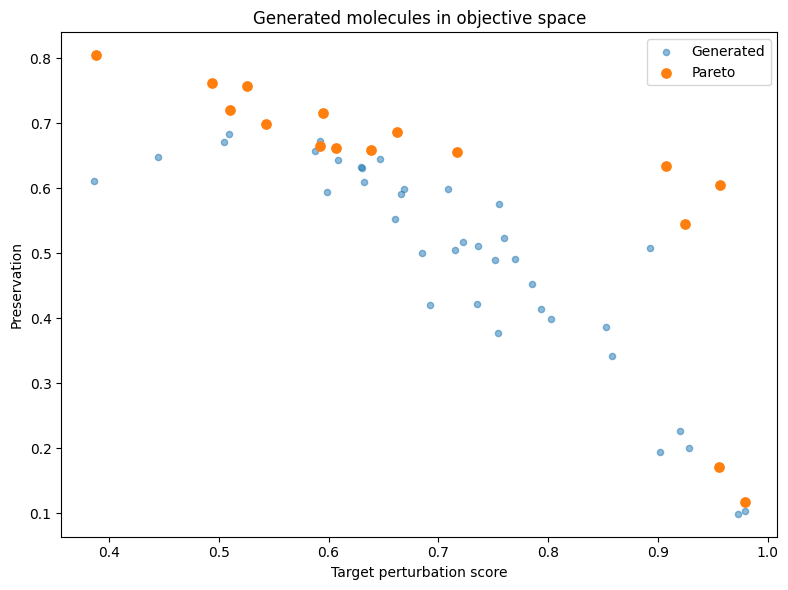

In [21]:
# ============================================================
# 22. Objective-space visualization
# ============================================================

plt.figure(figsize=(8, 6))
plt.scatter(
    results_df["TargetScore"],
    results_df["Preservation"],
    s=20,
    alpha=0.5,
    label="Generated"
)
plt.scatter(
    pareto_df["TargetScore"],
    pareto_df["Preservation"],
    s=45,
    label="Pareto"
)
plt.xlabel("Target perturbation score")
plt.ylabel("Preservation")
plt.title("Generated molecules in objective space")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Compare generated molecules with the training set

The final check asks whether the RL policy is producing genuinely new structures rather than only rediscovering the original 479 molecules.

In [22]:
# ============================================================
# 23. Novelty and top candidates
# ============================================================

results_df["Novel"] = ~results_df["SMILES"].isin(original_smiles)

print("Novel fraction:", results_df["Novel"].mean())

print("\nTop 20 novel molecules:")
display(
    results_df[results_df["Novel"]]
    .sort_values("Reward", ascending=False)
    .head(20)
)

# Save results for downstream inspection.
results_df.to_csv("generated_microbiome_candidates.csv", index=False)
pareto_df.to_csv("generated_microbiome_pareto_front.csv", index=False)

print("Saved:")
print("  generated_microbiome_candidates.csv")
print("  generated_microbiome_pareto_front.csv")

Novel fraction: 0.9259259259259259

Top 20 novel molecules:


,SMILES,TargetPerturbation,TargetScore,Preservation,Selectivity,OverallPerturbation,QED,MW,LogP,TPSA,HBD,HBA,Reward,Novel,Terminated
0,Clc1ccc(C(Cn2ccnc2)c2ccccc2)cc1,2.381807,0.907617,0.634552,0.771084,NaN,0.694736,282.774,4.3686,17.82,0.0,1.0,0.848428,True,True
1,OC(Cn1ccnc1)c1c(Cl)cc(Cl)cc1Cl,2.590206,0.924995,0.545560,0.735278,NaN,0.938450,291.565,3.5769,38.05,1.0,2.0,0.847904,True,True
2,Clc1ccc(C(Cn2ccnc2)c2ccc(Cl)cc2Cl)c(Cl)c1,3.133129,0.956419,0.605414,0.780916,NaN,0.512601,386.109,6.3288,17.82,0.0,1.0,0.831676,True,True
3,COC1=CC=C(c2cccc(Cl)c2)C(Cn2ccnc2)CC1,2.231570,0.892640,0.508555,0.700598,NaN,0.826844,314.816,4.5604,27.05,0.0,2.0,0.808730,True,True
4,CCC1c2ccccc2Sc2ccccc21,1.260913,0.716605,0.656629,0.686617,NaN,0.679261,226.344,4.6931,0.00,0.0,1.0,0.759256,True,True
5,NS(=O)c1ccccc1C1C(=O)c2ccccc2C1=O,1.019056,0.639064,0.659214,0.649139,NaN,0.855068,285.324,1.8307,77.23,1.0,3.0,0.737213,True,True
6,CCOC1=CC=C(c2ccccc2O)C(=S)NC(C)CC1,1.391900,0.751398,0.488947,0.620173,NaN,0.833582,303.427,3.7953,41.49,2.0,3.0,0.731853,True,True
7,C=CC1=C(C(=O)O)N2C(=O)CC2S1(=O)=O,1.917320,0.853000,0.386150,0.619575,NaN,0.641587,229.213,-0.5446,91.75,1.0,4.0,0.729395,True,True
8,Clc1ccc(Cl)c(Cl)c1Cl,1.406290,0.754949,0.575250,0.665100,NaN,0.447415,215.894,4.3002,0.00,0.0,0.0,0.729079,True,True
9,C=C1c2ccccc2C=Cc2ccccc21,1.233638,0.708769,0.598819,0.653794,NaN,0.513704,204.272,4.2319,0.00,0.0,0.0,0.720204,True,True


Saved:
  generated_microbiome_candidates.csv
  generated_microbiome_pareto_front.csv


,SMILES,MW,LogP,TPSA,HBD,HBA,Rings,RotB,QED,HeavyAtoms
0,Clc1ccc(C(Cn2ccnc2)c2ccccc2)cc1,282.774,4.3686,17.82,0,1,3,4,0.694736,20
1,OC(Cn1ccnc1)c1c(Cl)cc(Cl)cc1Cl,291.565,3.5769,38.05,1,2,2,3,0.938450,17
2,Clc1ccc(C(Cn2ccnc2)c2ccc(Cl)cc2Cl)c(Cl)c1,386.109,6.3288,17.82,0,1,3,4,0.512601,23
3,COC1=CC=C(c2cccc(Cl)c2)C(Cn2ccnc2)CC1,314.816,4.5604,27.05,0,2,3,4,0.826844,22
4,CCC1c2ccccc2Sc2ccccc21,226.344,4.6931,0.00,0,1,3,1,0.679261,16
5,NS(=O)c1ccccc1C1C(=O)c2ccccc2C1=O,285.324,1.8307,77.23,1,3,3,2,0.855068,20
6,CCOC1=CC=C(c2ccccc2O)C(=S)NC(C)CC1,303.427,3.7953,41.49,2,3,2,3,0.833582,21
7,C=CC1=C(C(=O)O)N2C(=O)CC2S1(=O)=O,229.213,-0.5446,91.75,1,4,2,2,0.641587,15
8,Clc1ccc(Cl)c(Cl)c1Cl,215.894,4.3002,0.00,0,0,1,0,0.447415,10
9,C=C1c2ccccc2C=Cc2ccccc21,204.272,4.2319,0.00,0,0,3,0,0.513704,16


,count,mean,std,min,25%,50%,75%,max
MW,54.0,296.907389,117.032284,87.034000,217.481250,293.428000,370.992250,691.85600
LogP,54.0,2.186754,2.673702,-5.547000,0.822700,2.670350,3.928950,7.28630
TPSA,54.0,66.170000,51.433614,0.000000,27.672500,65.555000,86.710000,236.36000
HBD,54.0,1.500000,1.870829,0.000000,0.000000,1.000000,2.000000,9.00000
HBA,54.0,3.944444,3.146826,0.000000,2.000000,3.000000,4.750000,14.00000
Rings,54.0,2.296296,0.924093,1.000000,1.250000,2.500000,3.000000,4.00000
RotB,54.0,3.888889,3.277520,0.000000,1.000000,3.500000,5.000000,12.00000
QED,54.0,0.577711,0.190333,0.174969,0.452617,0.554883,0.730214,0.93845
HeavyAtoms,54.0,20.537037,7.892468,6.000000,16.000000,20.500000,24.000000,48.00000


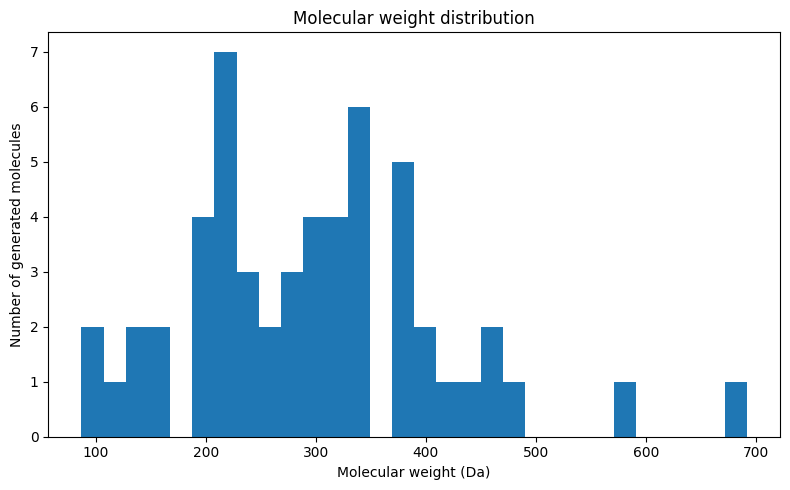

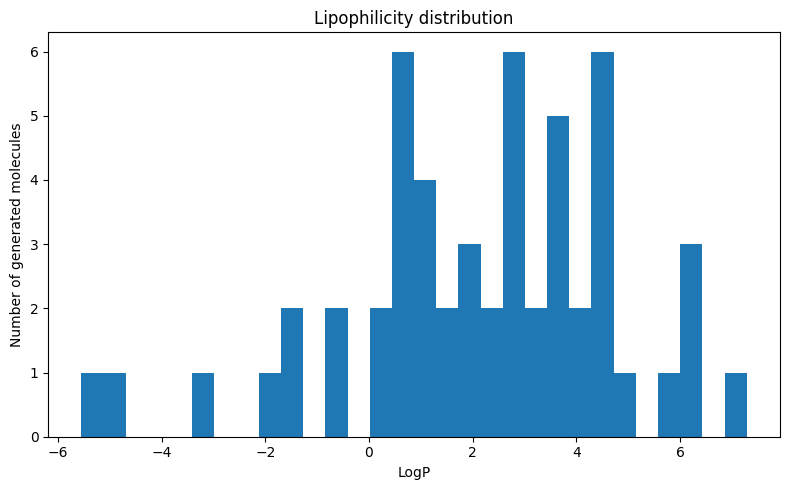

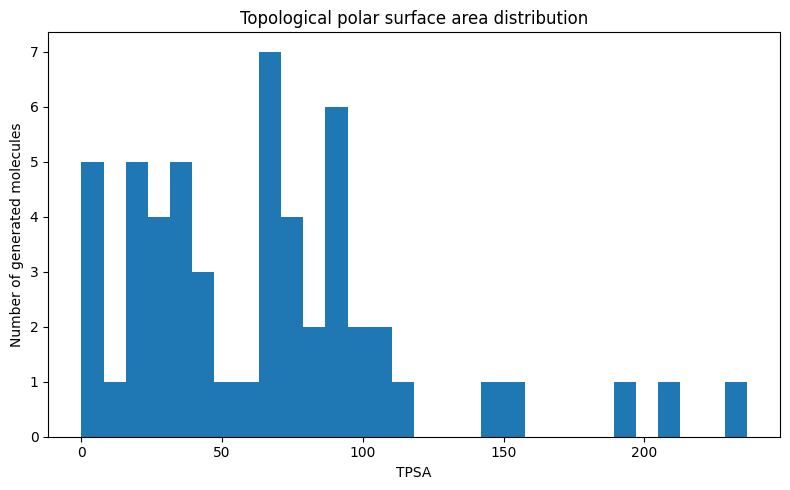

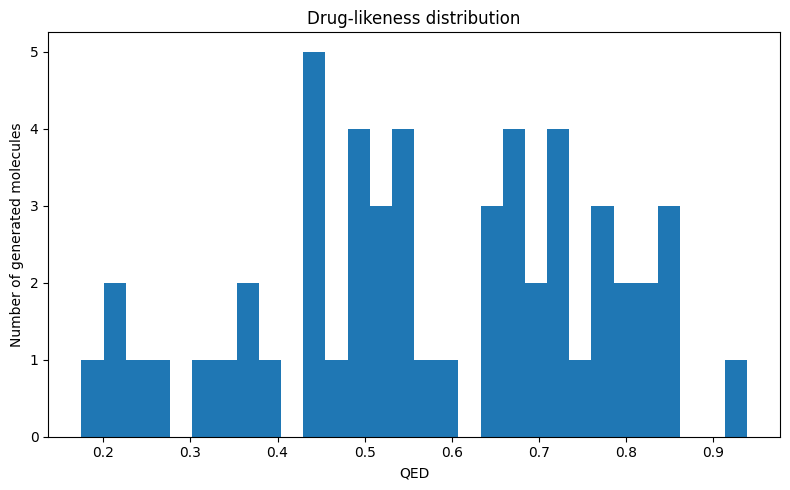

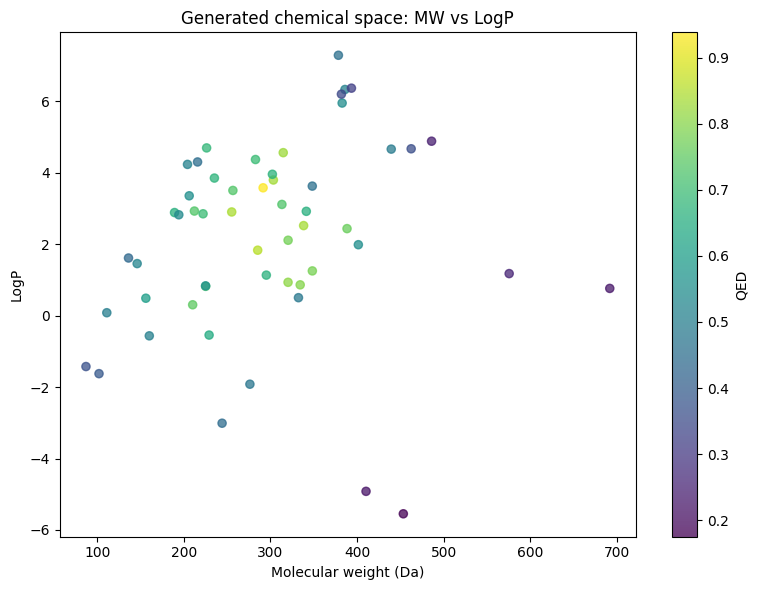

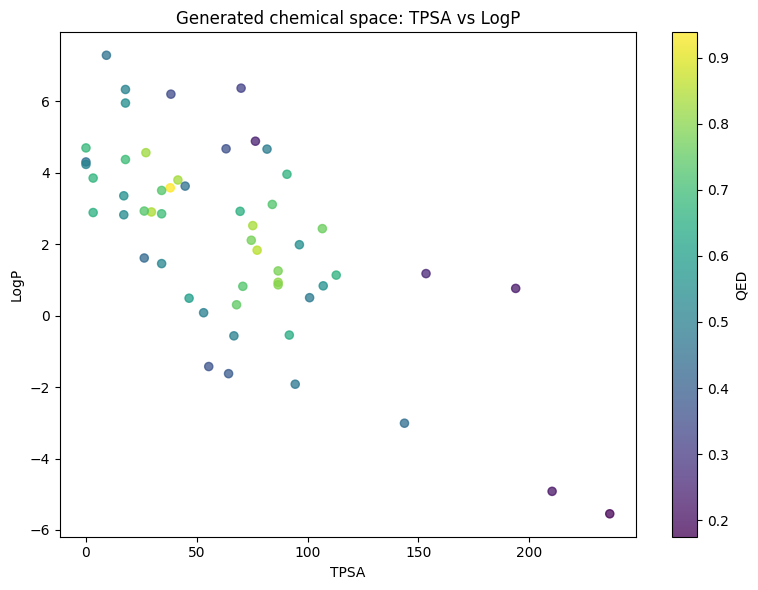

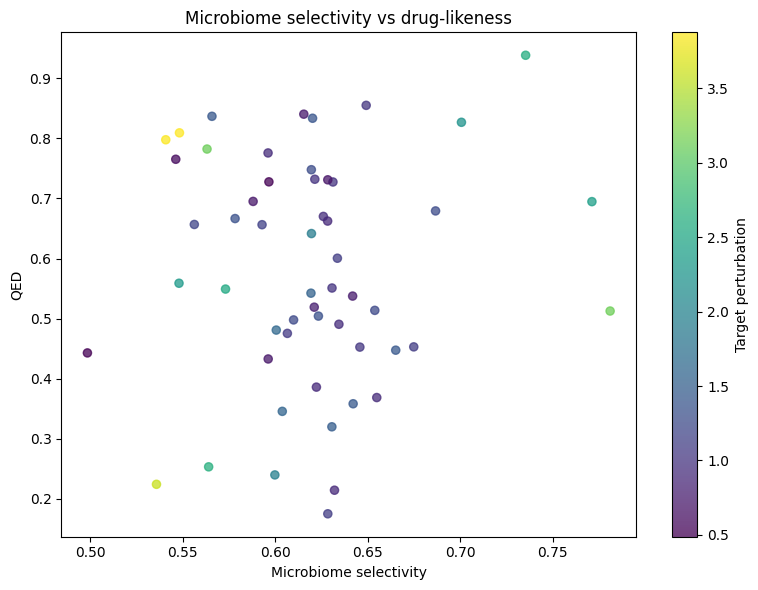

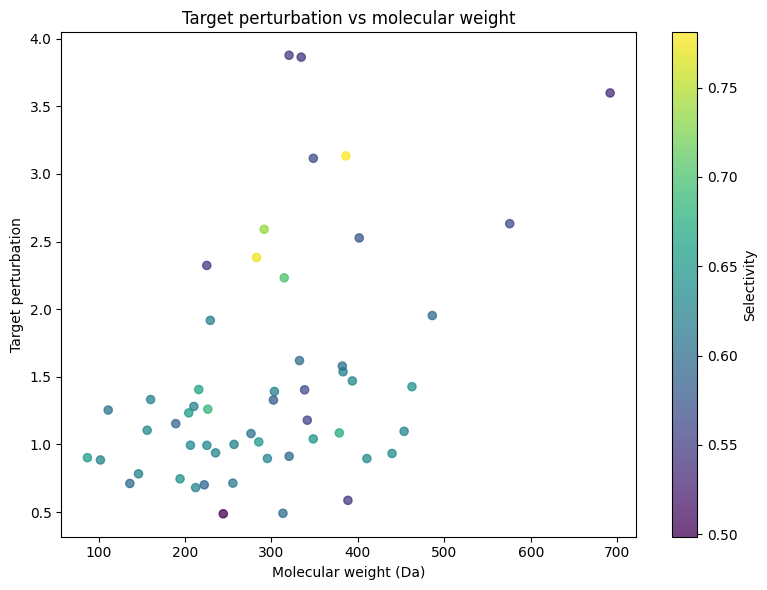

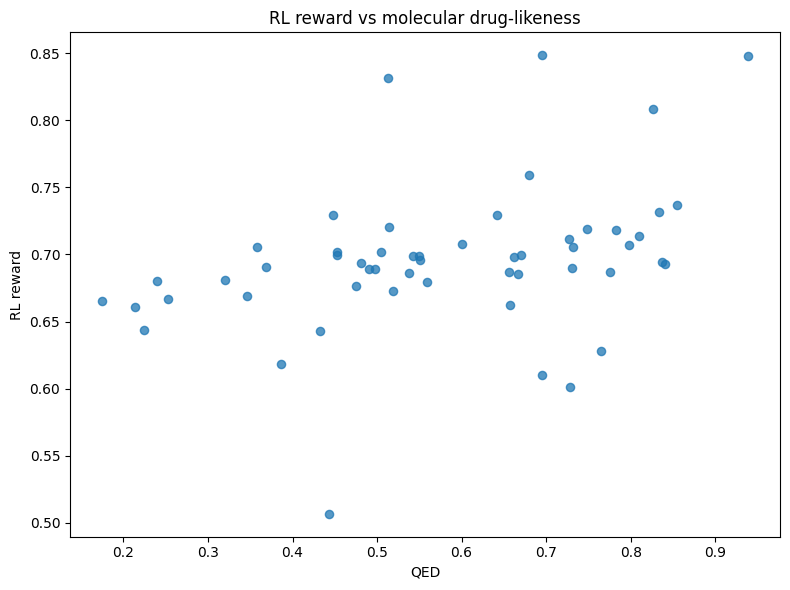

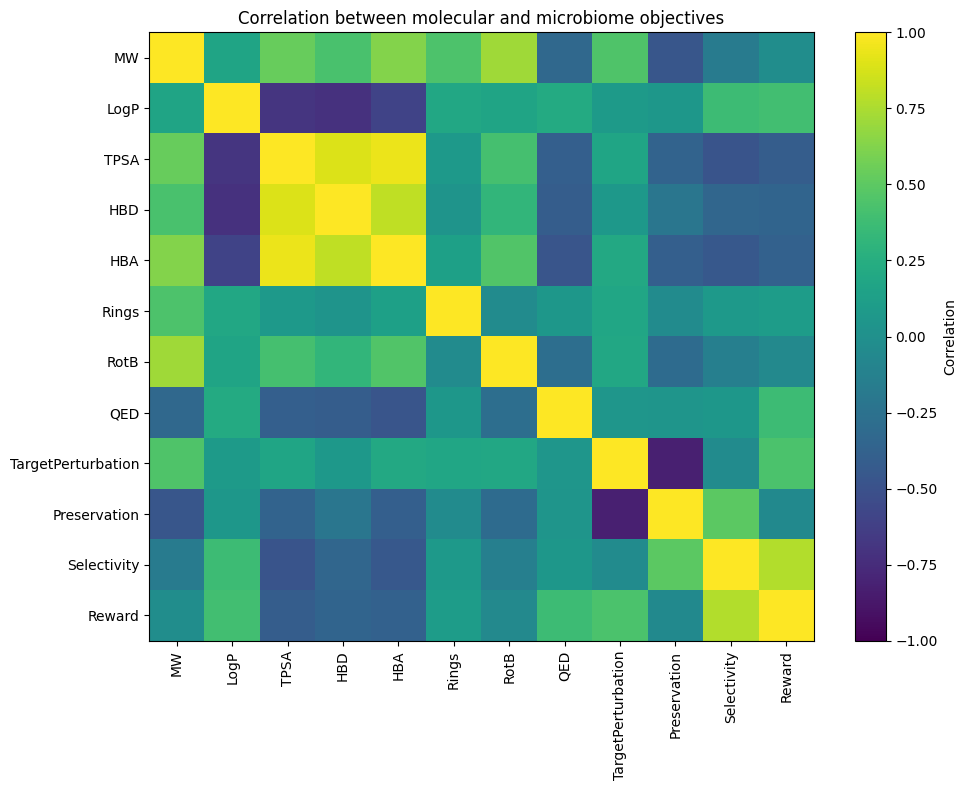

,SMILES,Reward,TargetPerturbation,Preservation,Selectivity,QED,MW,LogP,TPSA,HBD,HBA
0,Clc1ccc(C(Cn2ccnc2)c2ccccc2)cc1,0.848428,2.381807,0.634552,0.771084,0.694736,282.774,4.3686,17.82,0,1
1,OC(Cn1ccnc1)c1c(Cl)cc(Cl)cc1Cl,0.847904,2.590206,0.545560,0.735278,0.938450,291.565,3.5769,38.05,1,2
2,Clc1ccc(C(Cn2ccnc2)c2ccc(Cl)cc2Cl)c(Cl)c1,0.831676,3.133129,0.605414,0.780916,0.512601,386.109,6.3288,17.82,0,1
3,COC1=CC=C(c2cccc(Cl)c2)C(Cn2ccnc2)CC1,0.808730,2.231570,0.508555,0.700598,0.826844,314.816,4.5604,27.05,0,2
4,CCC1c2ccccc2Sc2ccccc21,0.759256,1.260913,0.656629,0.686617,0.679261,226.344,4.6931,0.00,0,1
5,NS(=O)c1ccccc1C1C(=O)c2ccccc2C1=O,0.737213,1.019056,0.659214,0.649139,0.855068,285.324,1.8307,77.23,1,3
6,CCOC1=CC=C(c2ccccc2O)C(=S)NC(C)CC1,0.731853,1.391900,0.488947,0.620173,0.833582,303.427,3.7953,41.49,2,3
7,C=CC1=C(C(=O)O)N2C(=O)CC2S1(=O)=O,0.729395,1.917320,0.386150,0.619575,0.641587,229.213,-0.5446,91.75,1,4
8,Clc1ccc(Cl)c(Cl)c1Cl,0.729079,1.406290,0.575250,0.665100,0.447415,215.894,4.3002,0.00,0,0
9,C=C1c2ccccc2C=Cc2ccccc21,0.720204,1.233638,0.598819,0.653794,0.513704,204.272,4.2319,0.00,0,0


In [23]:
# ============================================================
# 21. RDKit molecular properties and visualization
# ============================================================
#
# Calculate molecular properties directly from the generated
# SMILES using RDKit and visualize the generated chemical space.
#
# Properties:
#   MW       - molecular weight
#   LogP     - Crippen logP
#   TPSA     - topological polar surface area
#   HBD      - hydrogen bond donors
#   HBA      - hydrogen bond acceptors
#   Rings    - ring count
#   RotB     - rotatable bonds
#   QED      - quantitative estimate of drug-likeness
#
# ============================================================

from rdkit import Chem
from rdkit.Chem import (
    Descriptors,
    Crippen,
    QED,
    Lipinski,
    rdMolDescriptors
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Calculate RDKit properties
# ------------------------------------------------------------

def calculate_rdkit_properties(
    smiles
):

    mol = Chem.MolFromSmiles(
        smiles
    )

    if mol is None:
        return None

    return {
        "MW": Descriptors.MolWt(mol),

        "LogP": Crippen.MolLogP(mol),

        "TPSA": rdMolDescriptors.CalcTPSA(
            mol
        ),

        "HBD": Lipinski.NumHDonors(
            mol
        ),

        "HBA": Lipinski.NumHAcceptors(
            mol
        ),

        "Rings": Lipinski.RingCount(
            mol
        ),

        "RotB": Lipinski.NumRotatableBonds(
            mol
        ),

        "QED": QED.qed(
            mol
        ),

        "HeavyAtoms": mol.GetNumHeavyAtoms(),

        "Atoms": mol.GetNumAtoms()
    }


property_records = []

for smiles in results_df[
    "SMILES"
]:

    props = calculate_rdkit_properties(
        smiles
    )

    if props is None:

        property_records.append(
            {}
        )

    else:

        property_records.append(
            props
        )


rdkit_properties = pd.DataFrame(
    property_records
)


# ------------------------------------------------------------
# 2. Merge RDKit properties with results
# ------------------------------------------------------------

# Remove any duplicated property columns that may already
# exist from evaluate_candidate().

property_columns = [
    "MW",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "Rings",
    "RotB",
    "QED",
    "HeavyAtoms",
    "Atoms"
]

for col in property_columns:

    if col in results_df.columns:

        results_df = results_df.drop(
            columns=[col]
        )


results_df = pd.concat(
    [
        results_df.reset_index(drop=True),
        rdkit_properties.reset_index(drop=True)
    ],
    axis=1
)


# ------------------------------------------------------------
# 3. Display property summary
# ------------------------------------------------------------

display(
    results_df[
        [
            "SMILES",
            "MW",
            "LogP",
            "TPSA",
            "HBD",
            "HBA",
            "Rings",
            "RotB",
            "QED",
            "HeavyAtoms"
        ]
    ].head(25)
)


# ============================================================
# 4. Summary statistics
# ============================================================

property_summary = (
    results_df[
        [
            "MW",
            "LogP",
            "TPSA",
            "HBD",
            "HBA",
            "Rings",
            "RotB",
            "QED",
            "HeavyAtoms"
        ]
    ]
    .describe()
    .T
)

display(
    property_summary
)


# ============================================================
# 5. Molecular weight distribution
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    results_df["MW"].dropna(),
    bins=30
)

plt.xlabel(
    "Molecular weight (Da)"
)

plt.ylabel(
    "Number of generated molecules"
)

plt.title(
    "Molecular weight distribution"
)

plt.tight_layout()

plt.show()


# ============================================================
# 6. LogP distribution
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    results_df["LogP"].dropna(),
    bins=30
)

plt.xlabel(
    "LogP"
)

plt.ylabel(
    "Number of generated molecules"
)

plt.title(
    "Lipophilicity distribution"
)

plt.tight_layout()

plt.show()


# ============================================================
# 7. TPSA distribution
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    results_df["TPSA"].dropna(),
    bins=30
)

plt.xlabel(
    "TPSA"
)

plt.ylabel(
    "Number of generated molecules"
)

plt.title(
    "Topological polar surface area distribution"
)

plt.tight_layout()

plt.show()


# ============================================================
# 8. QED distribution
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    results_df["QED"].dropna(),
    bins=30
)

plt.xlabel(
    "QED"
)

plt.ylabel(
    "Number of generated molecules"
)

plt.title(
    "Drug-likeness distribution"
)

plt.tight_layout()

plt.show()


# ============================================================
# 9. Molecular weight vs LogP
# ============================================================

plt.figure(
    figsize=(8, 6)
)

scatter = plt.scatter(
    results_df["MW"],
    results_df["LogP"],
    c=results_df["QED"],
    s=35,
    alpha=0.75
)

plt.xlabel(
    "Molecular weight (Da)"
)

plt.ylabel(
    "LogP"
)

plt.title(
    "Generated chemical space: MW vs LogP"
)

plt.colorbar(
    scatter,
    label="QED"
)

plt.tight_layout()

plt.show()


# ============================================================
# 10. TPSA vs LogP
# ============================================================

plt.figure(
    figsize=(8, 6)
)

scatter = plt.scatter(
    results_df["TPSA"],
    results_df["LogP"],
    c=results_df["QED"],
    s=35,
    alpha=0.75
)

plt.xlabel(
    "TPSA"
)

plt.ylabel(
    "LogP"
)

plt.title(
    "Generated chemical space: TPSA vs LogP"
)

plt.colorbar(
    scatter,
    label="QED"
)

plt.tight_layout()

plt.show()


# ============================================================
# 11. QED vs microbiome selectivity
# ============================================================

if (
    "Selectivity" in results_df.columns
):

    plt.figure(
        figsize=(8, 6)
    )

    scatter = plt.scatter(
        results_df["Selectivity"],
        results_df["QED"],
        c=results_df["TargetPerturbation"],
        s=35,
        alpha=0.75
    )

    plt.xlabel(
        "Microbiome selectivity"
    )

    plt.ylabel(
        "QED"
    )

    plt.title(
        "Microbiome selectivity vs drug-likeness"
    )

    plt.colorbar(
        scatter,
        label="Target perturbation"
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 12. Target perturbation vs molecular weight
# ============================================================

if (
    "TargetPerturbation"
    in
    results_df.columns
):

    plt.figure(
        figsize=(8, 6)
    )

    scatter = plt.scatter(
        results_df["MW"],
        results_df["TargetPerturbation"],
        c=results_df["Selectivity"],
        s=35,
        alpha=0.75
    )

    plt.xlabel(
        "Molecular weight (Da)"
    )

    plt.ylabel(
        "Target perturbation"
    )

    plt.title(
        "Target perturbation vs molecular weight"
    )

    plt.colorbar(
        scatter,
        label="Selectivity"
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 13. Reward vs QED
# ============================================================

if (
    "Reward" in results_df.columns
):

    plt.figure(
        figsize=(8, 6)
    )

    plt.scatter(
        results_df["QED"],
        results_df["Reward"],
        s=35,
        alpha=0.75
    )

    plt.xlabel(
        "QED"
    )

    plt.ylabel(
        "RL reward"
    )

    plt.title(
        "RL reward vs molecular drug-likeness"
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 14. Correlation matrix
# ============================================================

correlation_columns = [
    "MW",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "Rings",
    "RotB",
    "QED",
    "TargetPerturbation",
    "Preservation",
    "Selectivity",
    "Reward"
]

correlation_columns = [
    c
    for c in correlation_columns
    if c in results_df.columns
]

corr = (
    results_df[
        correlation_columns
    ]
    .corr()
)


plt.figure(
    figsize=(10, 8)
)

plt.imshow(
    corr,
    aspect="auto",
    interpolation="nearest",
    vmin=-1,
    vmax=1
)

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

plt.title(
    "Correlation between molecular and microbiome objectives"
)

plt.colorbar(
    label="Correlation"
)

plt.tight_layout()

plt.show()


# ============================================================
# 15. Top molecules by reward
# ============================================================

top_molecules = (
    results_df
    .sort_values(
        "Reward",
        ascending=False
    )
    .head(25)
    .reset_index(
        drop=True
    )
)


display(
    top_molecules[
        [
            "SMILES",
            "Reward",
            "TargetPerturbation",
            "Preservation",
            "Selectivity",
            "QED",
            "MW",
            "LogP",
            "TPSA",
            "HBD",
            "HBA"
        ]
    ]
)

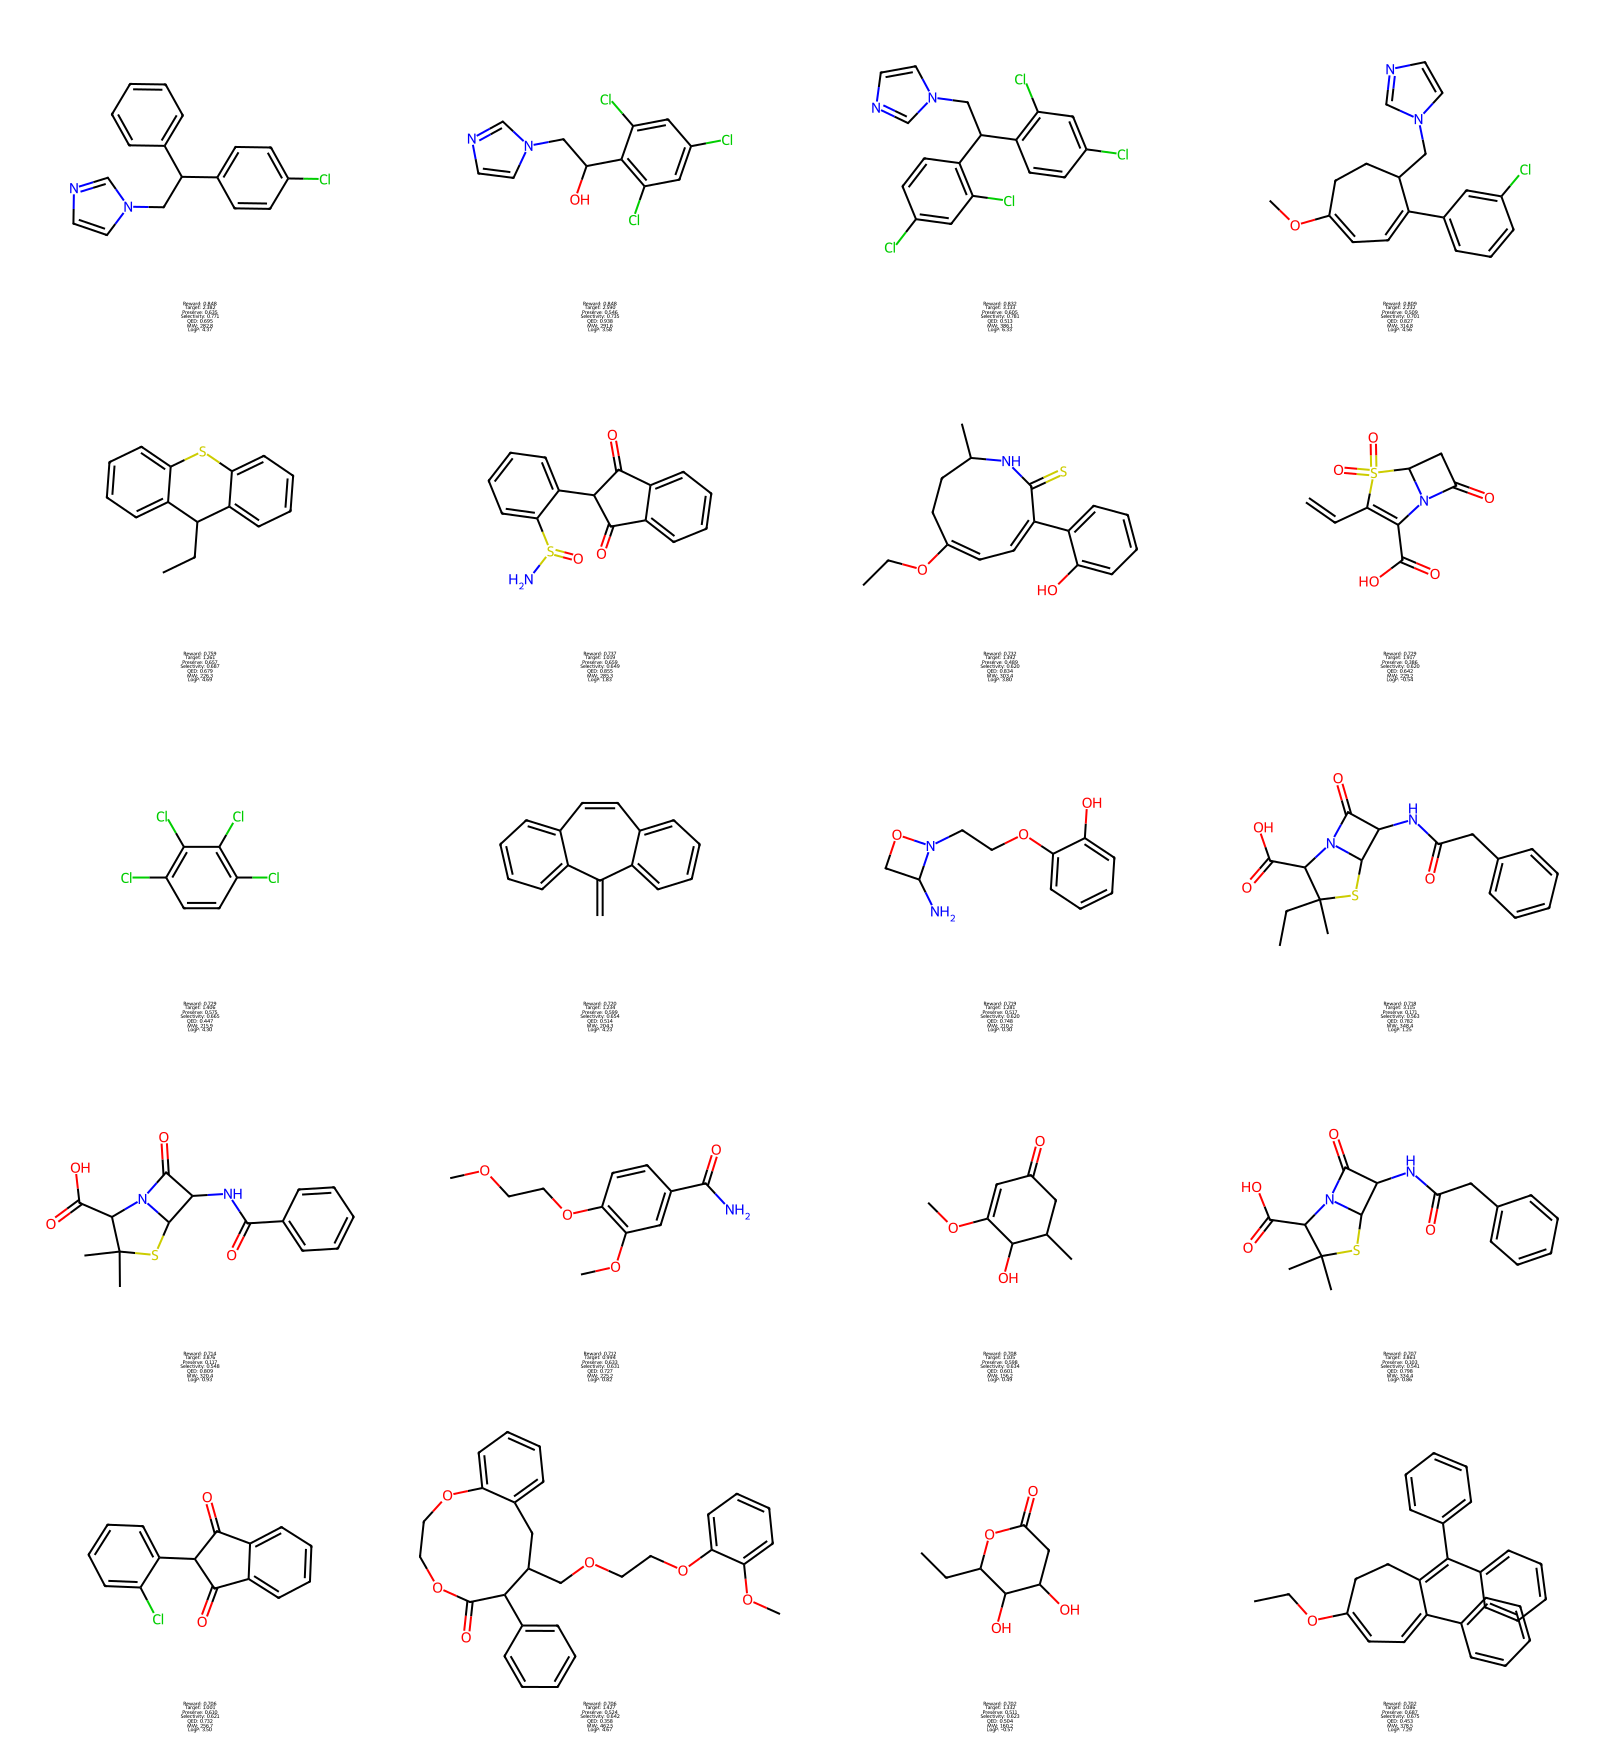

In [24]:
# ============================================================
# 22. Visualize generated molecular structures with properties
# ============================================================
#
# Each structure is displayed with a compact property summary:
#
#   Reward
#   Target perturbation
#   Preservation
#   Selectivity
#   QED
#   MW
#   LogP
#
# ============================================================

from rdkit import Chem
from rdkit.Chem import Draw


# ------------------------------------------------------------
# Number of molecules to display
# ------------------------------------------------------------

N_STRUCTURES = 20


# ------------------------------------------------------------
# Select top candidates
# ------------------------------------------------------------

top_structures = (
    results_df
    .sort_values(
        "Reward",
        ascending=False
    )
    .head(
        N_STRUCTURES
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Convert SMILES to RDKit molecules
# ------------------------------------------------------------

molecules = []
legends = []

for _, row in top_structures.iterrows():

    smiles = row["SMILES"]

    mol = Chem.MolFromSmiles(
        smiles
    )

    if mol is None:
        continue

    molecules.append(
        mol
    )

    # --------------------------------------------------------
    # Compact property overlay
    # --------------------------------------------------------

    legend = (
        f"Reward: {row.get('Reward', np.nan):.3f}\n"
        f"Target: {row.get('TargetPerturbation', np.nan):.3f}\n"
        f"Preserve: {row.get('Preservation', np.nan):.3f}\n"
        f"Selectivity: {row.get('Selectivity', np.nan):.3f}\n"
        f"QED: {row.get('QED', np.nan):.3f}\n"
        f"MW: {row.get('MW', np.nan):.1f}\n"
        f"LogP: {row.get('LogP', np.nan):.2f}"
    )

    legends.append(
        legend
    )


# ============================================================
# Draw molecules
# ============================================================

img = Draw.MolsToGridImage(
    molecules,
    molsPerRow=4,
    subImgSize=(400, 350),
    legends=legends,
    useSVG=False
)

display(
    img
)

<h2> Target-Conditioned Inverse Design of Gut Microbiome Modulators </h2>

That captures the three important ideas:

Target-conditioned — you provide the desired 40-dimensional perturbation vector.

Inverse design — desired biological response → molecular structures, rather than molecule → predicted response.

In [27]:
# ============================================================
# Target-profile optimization setup
# ============================================================

# Number of bacterial endpoints in the trained surrogate.
N_MICROBIOME_ENDPOINTS = len(strain_cols)

print(
    "Number of microbiome endpoints:",
    N_MICROBIOME_ENDPOINTS
)

assert N_MICROBIOME_ENDPOINTS == 40, (
    f"Expected 40 bacterial endpoints, "
    f"but found {N_MICROBIOME_ENDPOINTS}."
)

# ============================================================
# Define requested microbiome perturbation profile
# ============================================================

N_MICROBIOME_ENDPOINTS = len(strain_cols)

# One requested activity value for each bacterial endpoint.
desired_profile = np.array(
    [
        0.0,     # 0
        0.0,     # 1
        3.0,     # 2
        3.0,     # 3
        0.0,     # 4
        0.0,     # 5
        0.0,     # 6
        0.0,     # 7
        np.nan,  # 8
        0.0,     # 9
        0.0,     # 10
        2.5,     # 11
        np.nan,  # 12
        2.5,     # 13
        3.0,     # 14
        3.0,     # 15
        2.5,     # 16
        0.0,     # 17
        np.nan,  # 18
        0.0,     # 19
        np.nan,  # 20
        2.5,     # 21
        3.0,     # 22
        3.0,     # 23
        0.0,     # 24
        0.0,     # 25
        3.0,     # 26
        0.0,     # 27
        np.nan,  # 28
        0.0,     # 29
        0.0,     # 30
        np.nan,  # 31
        0.0,     # 32
        0.0,     # 33
        np.nan,  # 34
        2.0,     # 35
        2.0,     # 36
        0.0,     # 37
        0.0,     # 38
        np.nan   # 39
    ],
    dtype=np.float32
)


# ------------------------------------------------------------
# Validate target
# ------------------------------------------------------------

assert len(desired_profile) == N_MICROBIOME_ENDPOINTS, (
    f"Target has {len(desired_profile)} values, "
    f"but surrogate expects {N_MICROBIOME_ENDPOINTS}."
)

target_mask = np.isfinite(
    desired_profile
)

print(
    f"Constrained endpoints: "
    f"{target_mask.sum()}/{N_MICROBIOME_ENDPOINTS}"
)


# ------------------------------------------------------------
# Show exactly which organism each value refers to
# ------------------------------------------------------------

desired_profile_df = pd.DataFrame(
    {
        "Index":
            np.arange(
                N_MICROBIOME_ENDPOINTS
            ),

        "Strain":
            strain_cols,

        "DesiredPerturbation":
            desired_profile,

        "Constrained":
            target_mask
    }
)

display(
    desired_profile_df
)

Number of microbiome endpoints: 40
Constrained endpoints: 32/40


,Index,Strain,DesiredPerturbation,Constrained
0,0,Akkermansia muciniphila (NT5021),0.0,True
1,1,Bacteroides caccae (NT5050),0.0,True
2,2,Bacteroides fragilis (ET) (NT5033),3.0,True
3,3,Bacteroides fragilis (NT) (NT5003),3.0,True
4,4,Bacteroides ovatus (NT5054),0.0,True
5,5,Bacteroides thetaiotaomicron (NT5004),0.0,True
6,6,Bacteroides uniformis (NT5002),0.0,True
7,7,Bacteroides vulgatus (NT5001),0.0,True
8,8,Bacteroides xylanisolvens (NT5064),NaN,False
9,9,Bifidobacterium adolescentis (NT5022),0.0,True


In [28]:
# ============================================================
# 25. Normalize target perturbation vector
# ============================================================
#
# We normalize each bacterial endpoint using the training
# distribution of the surrogate.
#
# This prevents endpoints with intrinsically larger
# -log10(p) values from dominating the conditioning vector.
# ============================================================

Y_activity_array = np.asarray(
    Y_activity_work,
    dtype=np.float32
)

activity_mean = np.nanmean(
    Y_activity_array,
    axis=0
)

activity_std = np.nanstd(
    Y_activity_array,
    axis=0
)

# Avoid division by zero for invariant endpoints.
activity_std = np.where(
    activity_std < 1e-6,
    1.0,
    activity_std
)


# ------------------------------------------------------------
# Convert requested profile to normalized space
# ------------------------------------------------------------

target_normalized = np.zeros(
    N_MICROBIOME_ENDPOINTS,
    dtype=np.float32
)

target_normalized[
    target_mask
] = (
    (
        desired_profile[
            target_mask
        ]
        -
        activity_mean[
            target_mask
        ]
    )
    /
    activity_std[
        target_mask
    ]
)


# ------------------------------------------------------------
# For unconstrained endpoints use zero in the conditioning
# representation.
#
# The explicit mask is retained separately.
# ------------------------------------------------------------

target_normalized[
    ~target_mask
] = 0.0


print(
    "Normalized target vector:"
)

display(
    pd.DataFrame(
        {
            "strain": strain_cols,
            "raw_target":
                desired_profile,
            "normalized_target":
                target_normalized,
            "constrained":
                target_mask
        }
    )
)

Normalized target vector:


,strain,raw_target,normalized_target,constrained
0,Akkermansia muciniphila (NT5021),0.0,-0.559505,True
1,Bacteroides caccae (NT5050),0.0,-0.714889,True
2,Bacteroides fragilis (ET) (NT5033),3.0,0.837806,True
3,Bacteroides fragilis (NT) (NT5003),3.0,0.780342,True
4,Bacteroides ovatus (NT5054),0.0,-0.734964,True
5,Bacteroides thetaiotaomicron (NT5004),0.0,-0.731110,True
6,Bacteroides uniformis (NT5002),0.0,-0.811820,True
7,Bacteroides vulgatus (NT5001),0.0,-0.896678,True
8,Bacteroides xylanisolvens (NT5064),NaN,0.000000,False
9,Bifidobacterium adolescentis (NT5022),0.0,-0.687484,True


In [31]:
# ============================================================
# 26. Target-conditioned molecular generator
# ============================================================
#
# Learns:
#
#       P(SMILES | desired microbiome profile)
#
# The existing pretrained molecular policy supplies the
# chemistry. The requested microbiome perturbation profile is
# encoded into the initial hidden state of the GRU.
#
# This version matches the actual SmilesGRUPolicy architecture
# in this notebook:
#
#     embedding
#     gru
#     decoder
#
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# 1. Infer architecture from the actual policy
# ============================================================

VOCAB_SIZE = (
    policy.embedding.num_embeddings
)

EMB_DIM = (
    policy.embedding.embedding_dim
)

HIDDEN_DIM = (
    policy.gru.hidden_size
)

N_LAYERS = (
    policy.gru.num_layers
)

N_MICROBIOME_ENDPOINTS = (
    len(strain_cols)
)

TARGET_EMBED_DIM = 64


print(
    "Existing policy architecture:"
)

print(
    "Vocabulary size:",
    VOCAB_SIZE
)

print(
    "Embedding dimension:",
    EMB_DIM
)

print(
    "GRU hidden dimension:",
    HIDDEN_DIM
)

print(
    "GRU layers:",
    N_LAYERS
)

print(
    "Microbiome endpoints:",
    N_MICROBIOME_ENDPOINTS
)


# ============================================================
# 2. Conditional generator
# ============================================================

class ConditionalSMILESGenerator(
    nn.Module
):

    def __init__(
        self,
        base_policy,
        target_dim,
        target_embed_dim=64
    ):

        super().__init__()

        # ----------------------------------------------------
        # Infer dimensions from the actual base policy
        # ----------------------------------------------------

        self.vocab_size = (
            base_policy.embedding.num_embeddings
        )

        self.emb_dim = (
            base_policy.embedding.embedding_dim
        )

        self.hidden_dim = (
            base_policy.gru.hidden_size
        )

        self.n_layers = (
            base_policy.gru.num_layers
        )

        # ----------------------------------------------------
        # Copy chemistry architecture
        # ----------------------------------------------------

        self.embedding = nn.Embedding(
            self.vocab_size,
            self.emb_dim,
            padding_idx=PAD
        )

        self.gru = nn.GRU(
            input_size=self.emb_dim,
            hidden_size=self.hidden_dim,
            num_layers=self.n_layers,
            batch_first=True
        )

        self.decoder = nn.Linear(
            self.hidden_dim,
            self.vocab_size
        )

        # ----------------------------------------------------
        # Encode desired microbiome perturbation vector
        # ----------------------------------------------------

        self.target_encoder = nn.Sequential(

            nn.Linear(
                target_dim,
                target_embed_dim
            ),

            nn.LayerNorm(
                target_embed_dim
            ),

            nn.ReLU(),

            nn.Linear(
                target_embed_dim,
                target_embed_dim
            ),

            nn.ReLU()
        )

        # ----------------------------------------------------
        # Convert target embedding to initial GRU state
        # ----------------------------------------------------

        self.target_to_hidden = nn.Linear(
            target_embed_dim,
            self.n_layers *
            self.hidden_dim
        )

        # ----------------------------------------------------
        # Copy pretrained molecular-policy weights
        #
        # The chemistry network is initialized from the
        # existing pretrained / RL-fine-tuned policy.
        # ----------------------------------------------------

        self.embedding.load_state_dict(
            base_policy.embedding.state_dict()
        )

        self.gru.load_state_dict(
            base_policy.gru.state_dict()
        )

        self.decoder.load_state_dict(
            base_policy.decoder.state_dict()
        )


    # ========================================================
    # Target -> initial hidden state
    # ========================================================

    def encode_target(
        self,
        target_vector
    ):

        target_embedding = (
            self.target_encoder(
                target_vector
            )
        )

        hidden = (
            self.target_to_hidden(
                target_embedding
            )
        )

        hidden = hidden.view(
            target_vector.size(0),
            self.n_layers,
            self.hidden_dim
        )

        hidden = hidden.transpose(
            0,
            1
        ).contiguous()

        return hidden


    # ========================================================
    # Forward
    # ========================================================

    def forward(
        self,
        tokens,
        target_vector,
        hidden=None
    ):

        if hidden is None:

            hidden = self.encode_target(
                target_vector
            )

        x = self.embedding(
            tokens
        )

        out, hidden = self.gru(
            x,
            hidden
        )

        logits = self.decoder(
            out
        )

        return (
            logits,
            hidden
        )


    # ========================================================
    # Initialize hidden state
    # ========================================================

    def init_hidden(
        self,
        target_vector
    ):

        return self.encode_target(
            target_vector
        )


# ============================================================
# 3. Create conditional policy
# ============================================================

conditional_policy = (
    ConditionalSMILESGenerator(
        base_policy=policy,
        target_dim=N_MICROBIOME_ENDPOINTS,
        target_embed_dim=TARGET_EMBED_DIM
    )
    .to(device)
)


print(
    "\nConditional policy created successfully."
)

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in conditional_policy.parameters()
        if p.requires_grad
    )
)

Existing policy architecture:
Vocabulary size: 40
Embedding dimension: 128
GRU hidden dimension: 256
GRU layers: 2
Microbiome endpoints: 40

Conditional policy created successfully.
Trainable parameters: 746792


In [32]:
# ============================================================
# 27. Sample SMILES conditioned on desired microbiome profile
# ============================================================

def sample_conditional_smiles(
    model,
    target_vector,
    max_len=MAX_LEN,
    temperature=0.9
):

    model.train()

    # --------------------------------------------------------
    # Convert target to tensor
    # --------------------------------------------------------

    target_array = np.asarray(
        target_vector,
        dtype=np.float32
    )

    target_array = np.nan_to_num(
        target_array,
        nan=0.0
    )

    if len(
        target_array
    ) != N_MICROBIOME_ENDPOINTS:

        raise ValueError(
            "Target vector has incorrect length."
        )

    target_tensor = torch.tensor(
        target_array,
        dtype=torch.float32,
        device=device
    ).unsqueeze(0)

    # --------------------------------------------------------
    # Start sequence
    # --------------------------------------------------------

    token = torch.tensor(
        [[SOS]],
        dtype=torch.long,
        device=device
    )

    hidden = model.init_hidden(
        target_tensor
    )

    generated = []

    log_prob_terms = []

    terminated = False

    # --------------------------------------------------------
    # Generate sequence
    # --------------------------------------------------------

    for _ in range(
        max_len - 1
    ):

        logits, hidden = model(
            token,
            target_tensor,
            hidden
        )

        logits = logits[
            0,
            -1,
            :
        ]

        logits = (
            logits
            /
            max(
                temperature,
                1e-4
            )
        )

        # ----------------------------------------------------
        # Prevent invalid control tokens
        # ----------------------------------------------------

        logits = logits.clone()

        logits[
            PAD
        ] = -1e9

        logits[
            SOS
        ] = -1e9

        # ----------------------------------------------------
        # Differentiable action probabilities
        # ----------------------------------------------------

        log_probs = F.log_softmax(
            logits,
            dim=-1
        )

        probs = torch.exp(
            log_probs
        )

        action = torch.multinomial(
            probs,
            num_samples=1
        )

        action_id = int(
            action.item()
        )

        # IMPORTANT:
        # Retain graph for REINFORCE.
        log_prob_terms.append(
            log_probs[
                action_id
            ]
        )

        # ----------------------------------------------------
        # EOS
        # ----------------------------------------------------

        if action_id == EOS:

            terminated = True

            break

        generated.append(
            it2token[
                action_id
            ]
        )

        token = action.view(
            1,
            1
        )

    # --------------------------------------------------------
    # Sequence log probability
    # --------------------------------------------------------

    if log_prob_terms:

        sequence_log_prob = (
            torch.stack(
                log_prob_terms
            ).sum()
        )

    else:

        sequence_log_prob = (
            next(
                model.parameters()
            ).sum()
            *
            0.0
        )

    return (
        "".join(generated),
        sequence_log_prob,
        terminated
    )

In [33]:
# ============================================================
# 28. Test conditional generator
# ============================================================

test_smiles, test_log_prob, test_terminated = (
    sample_conditional_smiles(
        conditional_policy,
        target_normalized,
        max_len=MAX_LEN,
        temperature=0.9
    )
)


print(
    "Generated SMILES:",
    test_smiles
)

print(
    "Terminated:",
    test_terminated
)

print(
    "log_prob requires grad:",
    test_log_prob.requires_grad
)

print(
    "log_prob grad_fn:",
    test_log_prob.grad_fn
)


if not test_log_prob.requires_grad:

    raise RuntimeError(
        "Conditional sampler lost its autograd graph."
    )

Generated SMILES: CCOc1ccc(C(=O)NCCC(C)Cc2ccccc2)C12
Terminated: True
log_prob requires grad: True
log_prob grad_fn: <SumBackward0 object at 0x7ac1cd399720>


In [37]:
# ============================================================
# 29. Conditional REINFORCE for inverse microbiome design
# ============================================================

import numpy as np
import torch
import torch.nn.functional as F

from rdkit import Chem
from rdkit import RDLogger


# ------------------------------------------------------------
# Suppress RDKit parsing messages during generation
# ------------------------------------------------------------

RDLogger.DisableLog(
    "rdApp.error"
)


print("\n" + "=" * 70)
print("CONDITIONAL REINFORCE: INVERSE MICROBIOME DESIGN")
print("=" * 70)


# ============================================================
# 1. Configuration
# ============================================================

CONDITIONAL_RL_STEPS = 5    ####Increase this to over 100 for better results
CONDITIONAL_BATCH_SIZE = 24

CONDITIONAL_TEMPERATURE = 0.85
CONDITIONAL_RL_LR = 2e-4

PROFILE_ALPHA = 1.0

INVALID_REWARD = -0.50
TRUNCATED_PENALTY = 0.10
NOVELTY_BONUS = 0.03


print("\n[1] Configuration")
print("-" * 50)
print("RL steps            :", CONDITIONAL_RL_STEPS)
print("Batch size          :", CONDITIONAL_BATCH_SIZE)
print("Temperature         :", CONDITIONAL_TEMPERATURE)
print("Learning rate       :", CONDITIONAL_RL_LR)
print("Profile alpha       :", PROFILE_ALPHA)
print("Invalid reward      :", INVALID_REWARD)
print("Truncated penalty   :", TRUNCATED_PENALTY)
print("Novelty bonus       :", NOVELTY_BONUS)


# ============================================================
# 2. Check required objects
# ============================================================

print("\n[2] Checking required objects")
print("-" * 50)


required_objects = {
    "conditional_policy":
        "conditional_policy",

    "surrogate":
        "surrogate",

    "strain_cols":
        "strain_cols",

    "desired_profile":
        "desired_profile",

    "target_mask":
        "target_mask",

    "fingerprint_bits":
        "fingerprint_bits",

    "MAX_LEN":
        "MAX_LEN",

    "work_df":
        "work_df"
}


for name, obj_name in required_objects.items():

    if obj_name not in globals():

        raise RuntimeError(
            f"Required object '{obj_name}' is missing. "
            f"Run the corresponding earlier cell first."
        )

    print(
        f"OK: {obj_name}"
    )


# ============================================================
# 3. Basic target validation
# ============================================================

N_MICROBIOME_ENDPOINTS = len(
    strain_cols
)

print(
    "\nNumber of microbiome endpoints:",
    N_MICROBIOME_ENDPOINTS
)

print(
    "Constrained endpoints:",
    int(
        np.sum(
            target_mask
        )
    )
)

print(
    "Unconstrained endpoints:",
    int(
        np.sum(
            ~target_mask
        )
    )
)


if len(
    desired_profile
) != N_MICROBIOME_ENDPOINTS:

    raise ValueError(
        "desired_profile length does not match "
        "the number of microbiome endpoints."
    )


if target_mask.sum() == 0:

    raise ValueError(
        "At least one microbiome endpoint must be constrained."
    )


# ============================================================
# 4. Activity normalization
# ============================================================

print(
    "\n[3] Preparing activity normalization"
)

if (
    "activity_mean" not in globals()
    or
    "activity_std" not in globals()
):

    print(
        "activity_mean/activity_std not found."
    )

    print(
        "Computing them from Y_activity_work..."
    )

    Y_activity_array = np.asarray(
        Y_activity_work,
        dtype=np.float32
    )

    activity_mean = np.nanmean(
        Y_activity_array,
        axis=0
    )

    activity_std = np.nanstd(
        Y_activity_array,
        axis=0
    )

    activity_std = np.where(
        activity_std < 1e-6,
        1.0,
        activity_std
    )

    print(
        "Normalization parameters created."
    )

else:

    print(
        "Using existing activity normalization."
    )


# ============================================================
# 5. Normalize target profile
# ============================================================

target_normalized = np.zeros(
    N_MICROBIOME_ENDPOINTS,
    dtype=np.float32
)

target_normalized[
    target_mask
] = (
    (
        desired_profile[
            target_mask
        ]
        -
        activity_mean[
            target_mask
        ]
    )
    /
    activity_std[
        target_mask
    ]
)

target_normalized[
    ~target_mask
] = 0.0


print(
    "\nTarget profile normalized."
)


# ============================================================
# 6. Original training SMILES
# ============================================================

original_smiles = set(
    work_df[
        "canonical_smiles"
    ]
    .dropna()
    .astype(str)
)

print(
    "Original training molecules:",
    len(original_smiles)
)


# ============================================================
# 7. Surrogate prediction helper
# ============================================================

print(
    "\n[4] Defining surrogate prediction helper"
)


def surrogate_predict_smiles(
    smiles
):

    try:

        mol = Chem.MolFromSmiles(
            smiles
        )

        if mol is None:

            return None

        fp = fingerprint_bits(
            smiles
        )

        X_candidate = (
            fp.reshape(
                1,
                -1
            )
        )

        prediction = surrogate.predict(
            X_candidate
        )[0]

        prediction = np.asarray(
            prediction,
            dtype=np.float32
        )

        if len(
            prediction
        ) != N_MICROBIOME_ENDPOINTS:

            return None

        return prediction

    except Exception:

        return None


print(
    "Surrogate helper ready."
)


# ============================================================
# 8. Profile matching helper
# ============================================================

def calculate_profile_match(
    predicted_profile
):

    predicted_profile = np.asarray(
        predicted_profile,
        dtype=np.float32
    )

    if len(
        predicted_profile
    ) != N_MICROBIOME_ENDPOINTS:

        return (
            np.inf,
            0.0
        )

    predicted_normalized = (
        (
            predicted_profile
            -
            activity_mean
        )
        /
        activity_std
    )

    difference = (
        predicted_normalized[
            target_mask
        ]
        -
        target_normalized[
            target_mask
        ]
    )

    profile_distance = float(
        np.mean(
            difference ** 2
        )
    )

    profile_match = float(
        np.exp(
            -
            PROFILE_ALPHA
            *
            profile_distance
        )
    )

    return (
        profile_distance,
        profile_match
    )


print(
    "Profile-matching helper ready."
)


# ============================================================
# 9. Optimizer
# ============================================================

print(
    "\n[5] Creating optimizer"
)

conditional_optimizer = torch.optim.Adam(
    conditional_policy.parameters(),
    lr=CONDITIONAL_RL_LR
)

print(
    "Optimizer created."
)


# ============================================================
# 10. Diagnostic histories
# ============================================================

conditional_reward_history = []
conditional_match_history = []
conditional_valid_history = []
conditional_invalid_history = []
conditional_loss_history = []


# ============================================================
# 11. Count total trainable parameters
# ============================================================

trainable_parameters = sum(
    p.numel()
    for p in conditional_policy.parameters()
    if p.requires_grad
)

print(
    "Trainable parameters:",
    trainable_parameters
)


# ============================================================
# 12. Conditional REINFORCE
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "STARTING CONDITIONAL REINFORCE"
)

print(
    "=" * 70
)


conditional_policy.train()


for step in range(
    CONDITIONAL_RL_STEPS
):

    batch_log_probs = []
    batch_rewards = []
    batch_match_scores = []

    valid_count = 0
    invalid_count = 0


    # ========================================================
    # Generate batch
    # ========================================================

    for batch_item in range(
        CONDITIONAL_BATCH_SIZE
    ):

        # ----------------------------------------------------
        # Sample molecule
        # ----------------------------------------------------

        smiles, log_prob, terminated = (
            sample_conditional_smiles(
                conditional_policy,
                target_normalized,
                max_len=MAX_LEN,
                temperature=CONDITIONAL_TEMPERATURE
            )
        )


        # ----------------------------------------------------
        # Autograd check
        # ----------------------------------------------------

        if not log_prob.requires_grad:

            raise RuntimeError(
                "Detached log-probability returned by "
                "sample_conditional_smiles()."
            )


        # ----------------------------------------------------
        # Empty generation
        # ----------------------------------------------------

        if not smiles:

            batch_log_probs.append(
                log_prob
            )

            batch_rewards.append(
                INVALID_REWARD
            )

            batch_match_scores.append(
                0.0
            )

            invalid_count += 1

            continue


        # ----------------------------------------------------
        # Penalize incomplete generation
        # ----------------------------------------------------

        truncation_penalty = 0.0

        if not terminated:

            truncation_penalty = (
                TRUNCATED_PENALTY
            )


        # ====================================================
        # Predict microbiome response
        # ====================================================

        predicted_profile = (
            surrogate_predict_smiles(
                smiles
            )
        )


        # ----------------------------------------------------
        # Invalid molecule / prediction
        # ----------------------------------------------------

        if predicted_profile is None:

            batch_log_probs.append(
                log_prob
            )

            batch_rewards.append(
                INVALID_REWARD
            )

            batch_match_scores.append(
                0.0
            )

            invalid_count += 1

            continue


        # ====================================================
        # Compute target-profile matching
        # ====================================================

        profile_distance, match_score = (
            calculate_profile_match(
                predicted_profile
            )
        )


        # ----------------------------------------------------
        # Base reward
        # ----------------------------------------------------

        reward = (
            match_score
            -
            truncation_penalty
        )


        # ====================================================
        # Canonicalize molecule
        # ====================================================

        try:

            mol = Chem.MolFromSmiles(
                smiles
            )

            if mol is None:

                batch_log_probs.append(
                    log_prob
                )

                batch_rewards.append(
                    INVALID_REWARD
                )

                batch_match_scores.append(
                    0.0
                )

                invalid_count += 1

                continue


            candidate_smiles = (
                Chem.MolToSmiles(
                    mol,
                    canonical=True,
                    isomericSmiles=True
                )
            )

        except Exception:

            batch_log_probs.append(
                log_prob
            )

            batch_rewards.append(
                INVALID_REWARD
            )

            batch_match_scores.append(
                0.0
            )

            invalid_count += 1

            continue


        # ----------------------------------------------------
        # Reject disconnected compounds
        # ----------------------------------------------------

        if "." in candidate_smiles:

            batch_log_probs.append(
                log_prob
            )

            batch_rewards.append(
                INVALID_REWARD
            )

            batch_match_scores.append(
                0.0
            )

            invalid_count += 1

            continue


        # ----------------------------------------------------
        # Reject extremely small structures
        # ----------------------------------------------------

        if (
            mol.GetNumHeavyAtoms()
            < 5
        ):

            batch_log_probs.append(
                log_prob
            )

            batch_rewards.append(
                INVALID_REWARD
            )

            batch_match_scores.append(
                0.0
            )

            invalid_count += 1

            continue


        # ====================================================
        # Novelty bonus
        # ====================================================

        if (
            candidate_smiles
            not in
            original_smiles
        ):

            reward += (
                NOVELTY_BONUS
            )


        # ====================================================
        # Store successful trajectory
        # ====================================================

        batch_log_probs.append(
            log_prob
        )

        batch_rewards.append(
            reward
        )

        batch_match_scores.append(
            match_score
        )

        valid_count += 1


    # ========================================================
    # Skip empty batch
    # ========================================================

    if not batch_rewards:

        print(
            f"Step {step+1:03d}: "
            "no trajectories generated; skipping update."
        )

        continue


    # ========================================================
    # Reward tensor
    # ========================================================

    rewards = torch.tensor(
        batch_rewards,
        dtype=torch.float32,
        device=device
    )


    # ========================================================
    # Baseline
    # ========================================================

    baseline = (
        rewards.mean()
        .detach()
    )

    advantages = (
        rewards
        -
        baseline
    )


    # ========================================================
    # Advantage normalization
    # ========================================================

    if len(
        advantages
    ) > 1:

        advantage_std = (
            advantages.std(
                unbiased=False
            )
        )

        if (
            torch.isfinite(
                advantage_std
            )
            and
            advantage_std > 1e-8
        ):

            advantages = (
                advantages
                /
                advantage_std
            )


    # ========================================================
    # Stack log probabilities
    # ========================================================

    log_probs = torch.stack(
        batch_log_probs
    )


    if not log_probs.requires_grad:

        raise RuntimeError(
            "Stacked log-probabilities lost "
            "their autograd graph."
        )


    # ========================================================
    # REINFORCE loss
    # ========================================================

    loss = -(
        advantages.detach()
        *
        log_probs
    ).mean()


    # ========================================================
    # Policy update
    # ========================================================

    conditional_optimizer.zero_grad(
        set_to_none=True
    )

    loss.backward()


    gradient_norm = (
        torch.nn.utils.clip_grad_norm_(
            conditional_policy.parameters(),
            max_norm=1.0
        )
    )


    conditional_optimizer.step()


    # ========================================================
    # Diagnostics
    # ========================================================

    mean_reward = float(
        rewards.mean().item()
    )

    mean_match = float(
        np.mean(
            batch_match_scores
        )
    )

    valid_fraction = (
        valid_count
        /
        CONDITIONAL_BATCH_SIZE
    )

    invalid_fraction = (
        invalid_count
        /
        CONDITIONAL_BATCH_SIZE
    )

    loss_value = float(
        loss.detach().item()
    )

    gradient_value = float(
        gradient_norm
    )


    conditional_reward_history.append(
        mean_reward
    )

    conditional_match_history.append(
        mean_match
    )

    conditional_valid_history.append(
        valid_fraction
    )

    conditional_invalid_history.append(
        invalid_fraction
    )

    conditional_loss_history.append(
        loss_value
    )


    # ========================================================
    # Progress reporting
    # ========================================================

    if (
        (step + 1) % 10 == 0
        or
        step == 0
    ):

        print(
            f"\nStep {step+1:03d}/{CONDITIONAL_RL_STEPS}"
        )

        print(
            "-" * 50
        )

        print(
            "Mean reward       :",
            f"{mean_reward:.4f}"
        )

        print(
            "Profile match     :",
            f"{mean_match:.4f}"
        )

        print(
            "Valid fraction    :",
            f"{valid_fraction:.2%}"
        )

        print(
            "Invalid fraction  :",
            f"{invalid_fraction:.2%}"
        )

        print(
            "Loss              :",
            f"{loss_value:.4f}"
        )

        print(
            "Gradient norm     :",
            f"{gradient_value:.4f}"
        )

        print(
            "Constrained dims  :",
            int(target_mask.sum())
        )


# ============================================================
# 13. Final training summary
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "CONDITIONAL REINFORCE COMPLETE"
)

print(
    "=" * 70
)


if conditional_reward_history:

    print(
        "Initial mean reward:",
        f"{conditional_reward_history[0]:.4f}"
    )

    print(
        "Final mean reward  :",
        f"{conditional_reward_history[-1]:.4f}"
    )


if conditional_match_history:

    print(
        "Initial profile match:",
        f"{conditional_match_history[0]:.4f}"
    )

    print(
        "Final profile match  :",
        f"{conditional_match_history[-1]:.4f}"
    )


if conditional_valid_history:

    print(
        "Initial valid fraction:",
        f"{conditional_valid_history[0]:.2%}"
    )

    print(
        "Final valid fraction  :",
        f"{conditional_valid_history[-1]:.2%}"
    )


print(
    "\nTarget-conditioned policy is ready for generation."
)


CONDITIONAL REINFORCE: INVERSE MICROBIOME DESIGN

[1] Configuration
--------------------------------------------------
RL steps            : 5
Batch size          : 24
Temperature         : 0.85
Learning rate       : 0.0002
Profile alpha       : 1.0
Invalid reward      : -0.5
Truncated penalty   : 0.1
Novelty bonus       : 0.03

[2] Checking required objects
--------------------------------------------------
OK: conditional_policy
OK: surrogate
OK: strain_cols
OK: desired_profile
OK: target_mask
OK: fingerprint_bits
OK: MAX_LEN
OK: work_df

Number of microbiome endpoints: 40
Constrained endpoints: 32
Unconstrained endpoints: 8

[3] Preparing activity normalization
Using existing activity normalization.

Target profile normalized.
Original training molecules: 474

[4] Defining surrogate prediction helper
Surrogate helper ready.
Profile-matching helper ready.

[5] Creating optimizer
Optimizer created.
Trainable parameters: 746792

STARTING CONDITIONAL REINFORCE

Step 001/5
-------------

In [39]:
# ============================================================
# 30. Generate molecules from desired microbiome profile
# ============================================================
#
# The trained conditional_policy generates molecules conditioned
# on target_normalized.
#
# Each generated molecule is then evaluated directly through:
#
#     SMILES
#       ↓
#     Morgan fingerprint
#       ↓
#     microbiome surrogate
#       ↓
#     predicted 40-D activity profile
#
# The molecule is ranked by its distance from the requested
# microbiome perturbation profile.
# ============================================================

from rdkit import Chem
import numpy as np
import pandas as pd


# ============================================================
# 1. Configuration
# ============================================================

N_TARGET_MOLECULES = 100
TARGET_TEMPERATURE = 0.75
MAX_ATTEMPTS = 3000

PROFILE_ALPHA = 1.0


print("\n" + "=" * 70)
print("TARGET-CONDITIONED MOLECULE GENERATION")
print("=" * 70)

print(
    "Requested molecules:",
    N_TARGET_MOLECULES
)

print(
    "Sampling temperature:",
    TARGET_TEMPERATURE
)

print(
    "Maximum attempts:",
    MAX_ATTEMPTS
)

print(
    "Constrained endpoints:",
    int(target_mask.sum()),
    "/",
    len(target_mask)
)


# ============================================================
# 2. Required-object checks
# ============================================================

required_objects = [
    "conditional_policy",
    "sample_conditional_smiles",
    "surrogate",
    "fingerprint_bits",
    "target_normalized",
    "target_mask",
    "desired_profile",
    "activity_mean",
    "activity_std",
    "strain_cols"
]


for obj in required_objects:

    if obj not in globals():

        raise RuntimeError(
            f"Required object '{obj}' is missing. "
            f"Run the earlier cells first."
        )

print(
    "\nAll required objects are available."
)


# ============================================================
# 3. Original training compounds
# ============================================================

if "original_smiles" in globals():

    training_smiles = set(
        original_smiles
    )

else:

    training_smiles = set(
        work_df[
            "canonical_smiles"
        ]
        .dropna()
        .astype(str)
    )


print(
    "Training-set molecules:",
    len(training_smiles)
)


# ============================================================
# 4. Direct SMILES -> surrogate prediction
# ============================================================

def predict_profile_from_smiles(
    smiles
):

    try:

        mol = Chem.MolFromSmiles(
            smiles
        )

        if mol is None:

            return None


        # Reject disconnected structures.
        if "." in smiles:

            return None


        fingerprint = fingerprint_bits(
            smiles
        )


        X_candidate = (
            fingerprint
            .reshape(
                1,
                -1
            )
        )


        predicted_profile = (
            surrogate.predict(
                X_candidate
            )[0]
        )


        predicted_profile = np.asarray(
            predicted_profile,
            dtype=np.float32
        )


        if len(
            predicted_profile
        ) != len(
            strain_cols
        ):

            return None


        if not np.all(
            np.isfinite(
                predicted_profile
            )
        ):

            return None


        return predicted_profile


    except Exception:

        return None


# ============================================================
# 5. Target-profile distance
# ============================================================

def calculate_profile_distance(
    predicted_profile
):

    predicted_profile = np.asarray(
        predicted_profile,
        dtype=np.float32
    )


    # Normalize prediction using the same statistics used
    # to construct target_normalized.

    predicted_normalized = (
        (
            predicted_profile
            -
            activity_mean
        )
        /
        activity_std
    )


    difference = (
        predicted_normalized[
            target_mask
        ]
        -
        target_normalized[
            target_mask
        ]
    )


    profile_distance = float(
        np.mean(
            difference ** 2
        )
    )


    profile_match = float(
        np.exp(
            -
            PROFILE_ALPHA
            *
            profile_distance
        )
    )


    return (
        profile_distance,
        profile_match
    )


# ============================================================
# 6. Generate candidates
# ============================================================

target_candidates = []

seen = set()

attempts = 0
valid_count = 0
duplicate_count = 0
invalid_count = 0
truncated_count = 0


print(
    "\nStarting generation..."
)


while (
    len(target_candidates)
    <
    N_TARGET_MOLECULES
    and
    attempts
    <
    MAX_ATTEMPTS
):

    attempts += 1


    # --------------------------------------------------------
    # Generate conditioned molecule
    # --------------------------------------------------------

    try:

        smiles, log_prob, terminated = (
            sample_conditional_smiles(
                conditional_policy,
                target_normalized,
                max_len=MAX_LEN,
                temperature=TARGET_TEMPERATURE
            )
        )

    except Exception:

        invalid_count += 1

        continue


    # --------------------------------------------------------
    # Empty generation
    # --------------------------------------------------------

    if not smiles:

        invalid_count += 1

        continue


    # --------------------------------------------------------
    # Require EOS
    # --------------------------------------------------------

    if not terminated:

        truncated_count += 1

        continue


    # ========================================================
    # Canonicalize
    # ========================================================

    try:

        mol = Chem.MolFromSmiles(
            smiles
        )

        if mol is None:

            invalid_count += 1

            continue


        # ----------------------------------------------------
        # Only single-component molecules
        # ----------------------------------------------------

        if "." in smiles:

            invalid_count += 1

            continue


        canonical = (
            Chem.MolToSmiles(
                mol,
                canonical=True,
                isomericSmiles=True
            )
        )


    except Exception:

        invalid_count += 1

        continue


    # ========================================================
    # Remove duplicates
    # ========================================================

    if canonical in seen:

        duplicate_count += 1

        continue


    seen.add(
        canonical
    )


    # ========================================================
    # Basic molecular-size sanity check
    # ========================================================

    if (
        mol.GetNumHeavyAtoms()
        < 5
    ):

        invalid_count += 1

        continue


    # ========================================================
    # Predict microbiome perturbation directly
    # ========================================================

    predicted_profile = (
        predict_profile_from_smiles(
            canonical
        )
    )


    if predicted_profile is None:

        invalid_count += 1

        continue


    # ========================================================
    # Compare to requested profile
    # ========================================================

    profile_distance, profile_match = (
        calculate_profile_distance(
            predicted_profile
        )
    )


    # ========================================================
    # Optional novelty indicator
    # ========================================================

    is_novel = (
        canonical
        not in
        training_smiles
    )


    # ========================================================
    # Store candidate
    # ========================================================

    target_candidates.append(
        {
            "SMILES":
                canonical,

            "ProfileDistance":
                profile_distance,

            "ProfileMatch":
                profile_match,

            "Novel":
                is_novel,

            "Terminated":
                terminated,

            "PredictedProfile":
                predicted_profile,

            "LogProbability":
                float(
                    log_prob
                    .detach()
                    .cpu()
                    .item()
                )
        }
    )


    valid_count += 1


    # ========================================================
    # Progress
    # ========================================================

    if (
        len(target_candidates) % 10 == 0
        or
        len(target_candidates)
        == N_TARGET_MOLECULES
    ):

        print(
            f"Generated "
            f"{len(target_candidates)}/"
            f"{N_TARGET_MOLECULES} | "
            f"attempts={attempts} | "
            f"invalid={invalid_count} | "
            f"duplicates={duplicate_count} | "
            f"truncated={truncated_count}"
        )


# ============================================================
# 7. Convert to DataFrame
# ============================================================

target_generated_df = pd.DataFrame(
    target_candidates
)


if target_generated_df.empty:

    raise RuntimeError(
        "No valid target-conditioned molecules were generated. "
        "Increase MAX_ATTEMPTS or adjust the generation temperature."
    )


# ============================================================
# 8. Rank by target-profile matching
# ============================================================

target_generated_df = (
    target_generated_df
    .sort_values(
        [
            "ProfileDistance",
            "ProfileMatch"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 9. Add rank
# ============================================================

target_generated_df[
    "Rank"
] = np.arange(
    1,
    len(target_generated_df) + 1
)


# ============================================================
# 10. Summary
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "TARGET-CONDITIONED GENERATION COMPLETE"
)

print(
    "=" * 70
)

print(
    "Requested molecules:",
    N_TARGET_MOLECULES
)

print(
    "Generated unique molecules:",
    len(target_generated_df)
)

print(
    "Total attempts:",
    attempts
)

print(
    "Valid molecules:",
    valid_count
)

print(
    "Invalid molecules:",
    invalid_count
)

print(
    "Duplicates:",
    duplicate_count
)

print(
    "Truncated generations:",
    truncated_count
)


print(
    "\nBest profile match:",
    f"{target_generated_df['ProfileMatch'].max():.4f}"
)

print(
    "Best profile distance:",
    f"{target_generated_df['ProfileDistance'].min():.4f}"
)

print(
    "Novel candidate fraction:",
    f"{target_generated_df['Novel'].mean():.2%}"
)


# ============================================================
# 11. Display top candidates
# ============================================================

display(
    target_generated_df[
        [
            "Rank",
            "SMILES",
            "ProfileDistance",
            "ProfileMatch",
            "Novel",
            "Terminated"
        ]
    ].head(25)
)


TARGET-CONDITIONED MOLECULE GENERATION
Requested molecules: 100
Sampling temperature: 0.75
Maximum attempts: 3000
Constrained endpoints: 32 / 40

All required objects are available.
Training-set molecules: 474

Starting generation...
Generated 10/100 | attempts=24 | invalid=9 | duplicates=5 | truncated=0
Generated 20/100 | attempts=66 | invalid=32 | duplicates=14 | truncated=0
Generated 30/100 | attempts=88 | invalid=37 | duplicates=21 | truncated=0
Generated 40/100 | attempts=125 | invalid=50 | duplicates=35 | truncated=0
Generated 50/100 | attempts=160 | invalid=64 | duplicates=46 | truncated=0
Generated 60/100 | attempts=210 | invalid=83 | duplicates=67 | truncated=0
Generated 70/100 | attempts=258 | invalid=104 | duplicates=84 | truncated=0
Generated 80/100 | attempts=292 | invalid=112 | duplicates=100 | truncated=0
Generated 90/100 | attempts=330 | invalid=128 | duplicates=112 | truncated=0
Generated 100/100 | attempts=370 | invalid=144 | duplicates=126 | truncated=0

TARGET-COND

,Rank,SMILES,ProfileDistance,ProfileMatch,Novel,Terminated
0,1,COc1ccc(C(=O)C(Cl)Cl)cc1,0.481907,0.617604,True,True
1,2,O=C1OCCN1c1ncc([N+](=O)[O-])n1CCO,0.483034,0.616909,True,True
2,3,COCCOC1=C(O)C(=O)C(O)=C1,0.492089,0.611348,True,True
3,4,O=C1OCCN1c1ncc([N+](=O)[O-])o1,0.494488,0.609883,True,True
4,5,CCOc1ccc(C(=O)C(Cl)Cl)cc1,0.501938,0.605356,True,True
5,6,O=c1[nH]cccc1O,0.504174,0.604005,True,True
6,7,CCn1ccc(C(=O)O)c1,0.513038,0.598674,True,True
7,8,O=C(O)c1ccccc1O,0.522485,0.593045,True,True
8,9,O=C1OCCN1c1ncccc1O,0.523306,0.592558,True,True
9,10,O=C1N=C([O-])CN1N=Cc1ccc(O)cc1,0.524111,0.592081,True,True



DESIRED VS PREDICTED MICROBIOME PROFILES


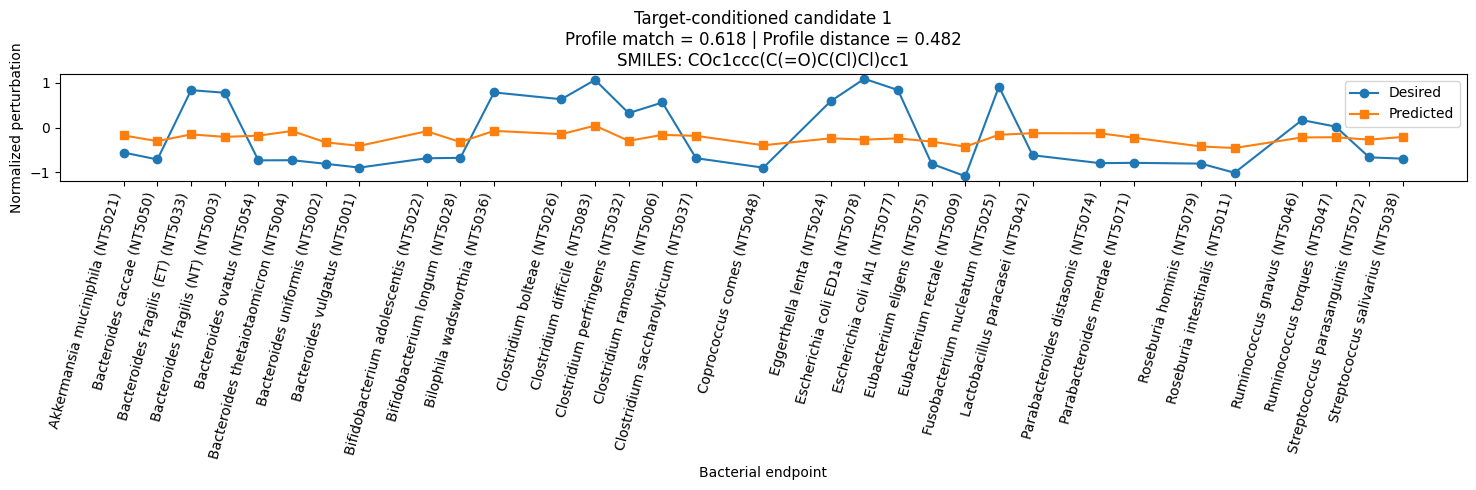

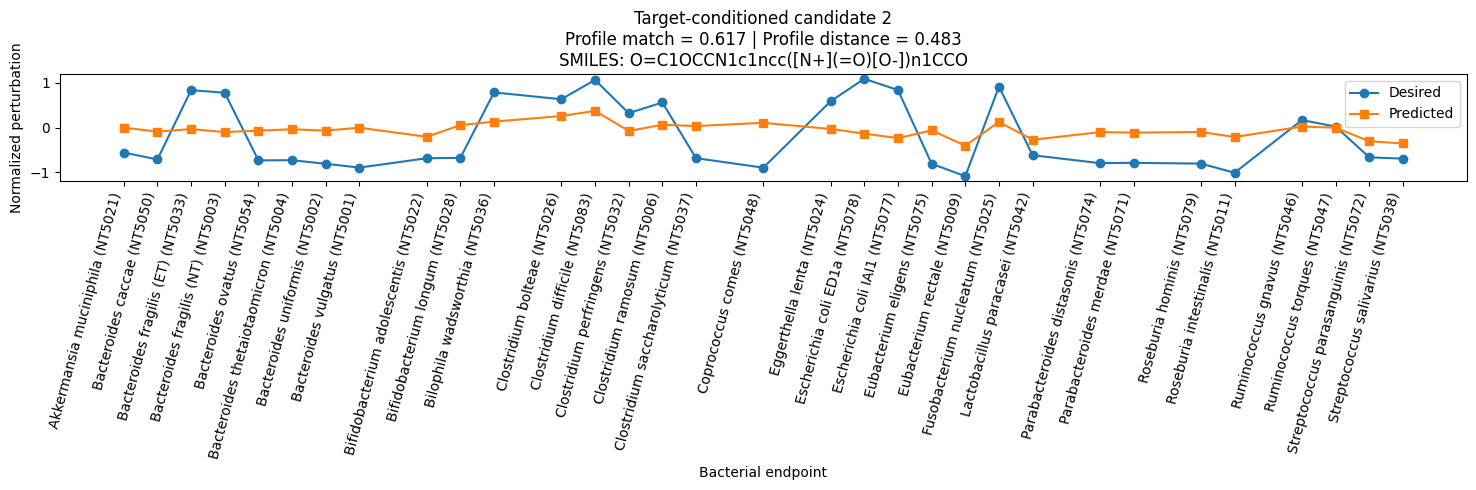

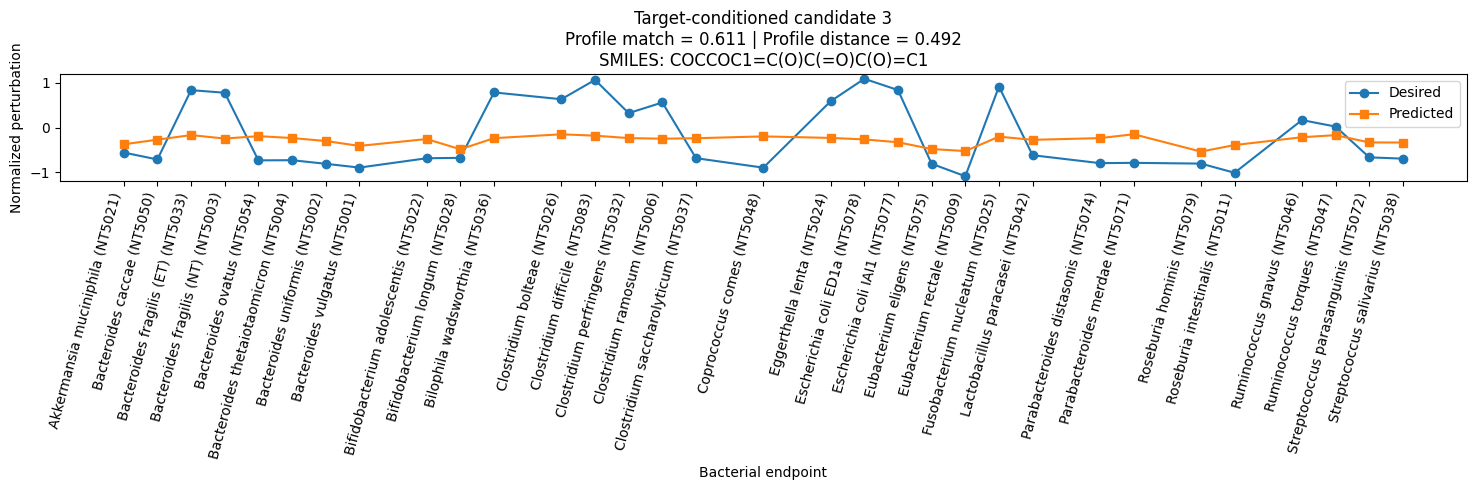

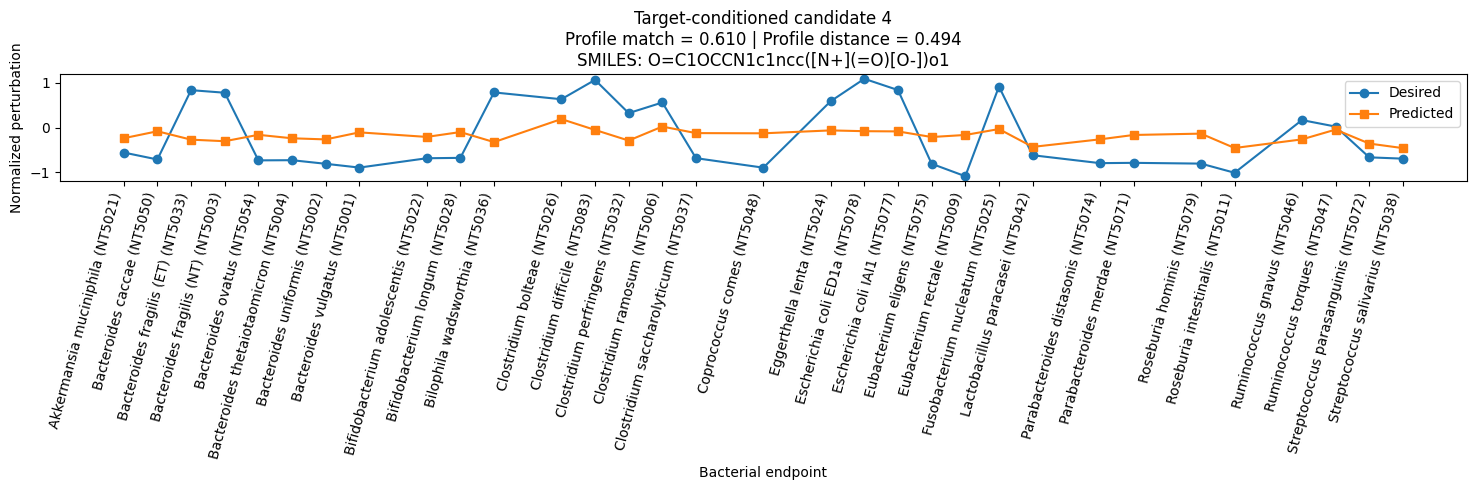

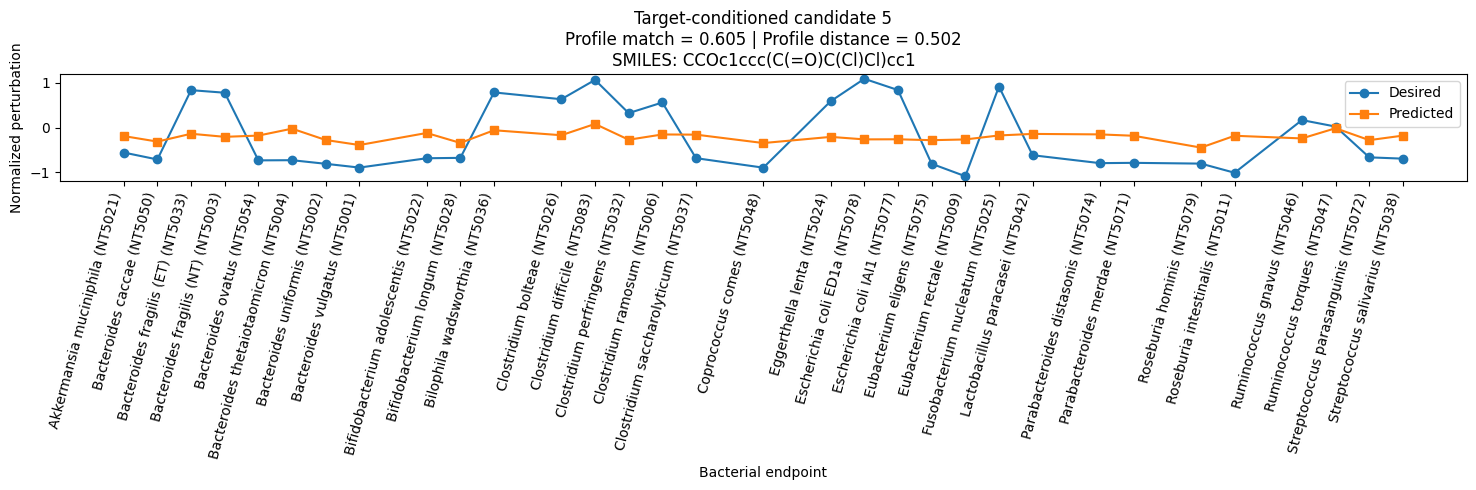


Numerical profile comparison:


,Candidate,SMILES,Strain,Desired,Predicted,AbsoluteError
0,1,COc1ccc(C(=O)C(Cl)Cl)cc1,Akkermansia muciniphila (NT5021),-0.559505,-0.177192,0.382314
1,1,COc1ccc(C(=O)C(Cl)Cl)cc1,Bacteroides caccae (NT5050),-0.714889,-0.303897,0.410993
2,1,COc1ccc(C(=O)C(Cl)Cl)cc1,Bacteroides fragilis (ET) (NT5033),0.837806,-0.152774,0.990580
3,1,COc1ccc(C(=O)C(Cl)Cl)cc1,Bacteroides fragilis (NT) (NT5003),0.780342,-0.208845,0.989186
4,1,COc1ccc(C(=O)C(Cl)Cl)cc1,Bacteroides ovatus (NT5054),-0.734964,-0.181322,0.553642
5,1,COc1ccc(C(=O)C(Cl)Cl)cc1,Bacteroides thetaiotaomicron (NT5004),-0.731110,-0.077058,0.654052
6,1,COc1ccc(C(=O)C(Cl)Cl)cc1,Bacteroides uniformis (NT5002),-0.811820,-0.331018,0.480802
7,1,COc1ccc(C(=O)C(Cl)Cl)cc1,Bacteroides vulgatus (NT5001),-0.896678,-0.409963,0.486715
8,1,COc1ccc(C(=O)C(Cl)Cl)cc1,Bifidobacterium adolescentis (NT5022),-0.687484,-0.082444,0.605040
9,1,COc1ccc(C(=O)C(Cl)Cl)cc1,Bifidobacterium longum (NT5028),-0.678636,-0.324584,0.354052


In [41]:
# ============================================================
# 31. Desired vs predicted microbiome profile
# ============================================================
#
# Compare the requested microbiome perturbation profile with
# the profile predicted for the best target-conditioned
# generated molecules.
#
# Uses the PredictedProfile already stored by Cell 30.
# No additional surrogate prediction helper is required.
# ============================================================

TOP_N = min(
    5,
    len(target_generated_df)
)


if TOP_N == 0:

    raise RuntimeError(
        "target_generated_df is empty. "
        "Run Cell 30 first."
    )


print(
    "\n" + "=" * 70
)

print(
    "DESIRED VS PREDICTED MICROBIOME PROFILES"
)

print(
    "=" * 70
)


# ------------------------------------------------------------
# Check that predicted profiles are available
# ------------------------------------------------------------

if (
    "PredictedProfile"
    not in
    target_generated_df.columns
):

    raise RuntimeError(
        "PredictedProfile is not present in "
        "target_generated_df. Re-run Cell 30."
    )


# ------------------------------------------------------------
# Endpoint indices
# ------------------------------------------------------------

N_MICROBIOME_ENDPOINTS = len(
    strain_cols
)

x = np.arange(
    N_MICROBIOME_ENDPOINTS
)


# ------------------------------------------------------------
# Plot top candidates
# ------------------------------------------------------------

for i in range(
    TOP_N
):

    row = target_generated_df.iloc[
        i
    ]


    smiles = row[
        "SMILES"
    ]


    # --------------------------------------------------------
    # Retrieve profile calculated in Cell 30
    # --------------------------------------------------------

    predicted_profile = np.asarray(
        row[
            "PredictedProfile"
        ],
        dtype=np.float32
    )


    if len(
        predicted_profile
    ) != N_MICROBIOME_ENDPOINTS:

        print(
            f"Skipping candidate {i+1}: "
            "predicted profile has incorrect length."
        )

        continue


    # --------------------------------------------------------
    # Normalize predicted profile
    # --------------------------------------------------------

    predicted_normalized = (
        (
            predicted_profile
            -
            activity_mean
        )
        /
        activity_std
    )


    # ========================================================
    # Plot
    # ========================================================

    plt.figure(
        figsize=(15, 5)
    )


    plt.plot(
        x[target_mask],
        target_normalized[
            target_mask
        ],
        "o-",
        label="Desired"
    )


    plt.plot(
        x[target_mask],
        predicted_normalized[
            target_mask
        ],
        "s-",
        label="Predicted"
    )


    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    plt.xlabel(
        "Bacterial endpoint"
    )

    plt.ylabel(
        "Normalized perturbation"
    )


    plt.xticks(
        x[target_mask],
        [
            strain_cols[j]
            for j in x[target_mask]
        ],
        rotation=75,
        ha="right"
    )


    profile_match = row.get(
        "ProfileMatch",
        np.nan
    )


    profile_distance = row.get(
        "ProfileDistance",
        np.nan
    )


    plt.title(
        f"Target-conditioned candidate {i+1}\n"
        f"Profile match = {profile_match:.3f} | "
        f"Profile distance = {profile_distance:.3f}\n"
        f"SMILES: {smiles}"
    )


    plt.legend()

    plt.tight_layout()

    plt.show()


# ============================================================
# 32. Numerical comparison table
# ============================================================

comparison_rows = []


for i in range(
    TOP_N
):

    row = target_generated_df.iloc[
        i
    ]


    predicted_profile = np.asarray(
        row[
            "PredictedProfile"
        ],
        dtype=np.float32
    )


    if len(
        predicted_profile
    ) != N_MICROBIOME_ENDPOINTS:

        continue


    predicted_normalized = (
        (
            predicted_profile
            -
            activity_mean
        )
        /
        activity_std
    )


    for j, strain in enumerate(
        strain_cols
    ):

        if not target_mask[j]:

            continue


        comparison_rows.append(
            {
                "Candidate":
                    i + 1,

                "SMILES":
                    row["SMILES"],

                "Strain":
                    strain,

                "Desired":
                    target_normalized[j],

                "Predicted":
                    predicted_normalized[j],

                "AbsoluteError":
                    abs(
                        predicted_normalized[j]
                        -
                        target_normalized[j]
                    )
            }
        )


profile_comparison_df = pd.DataFrame(
    comparison_rows
)


print(
    "\nNumerical profile comparison:"
)

display(
    profile_comparison_df.head(50)
)


TOP TARGET-CONDITIONED MOLECULES
Displaying 12 candidates.


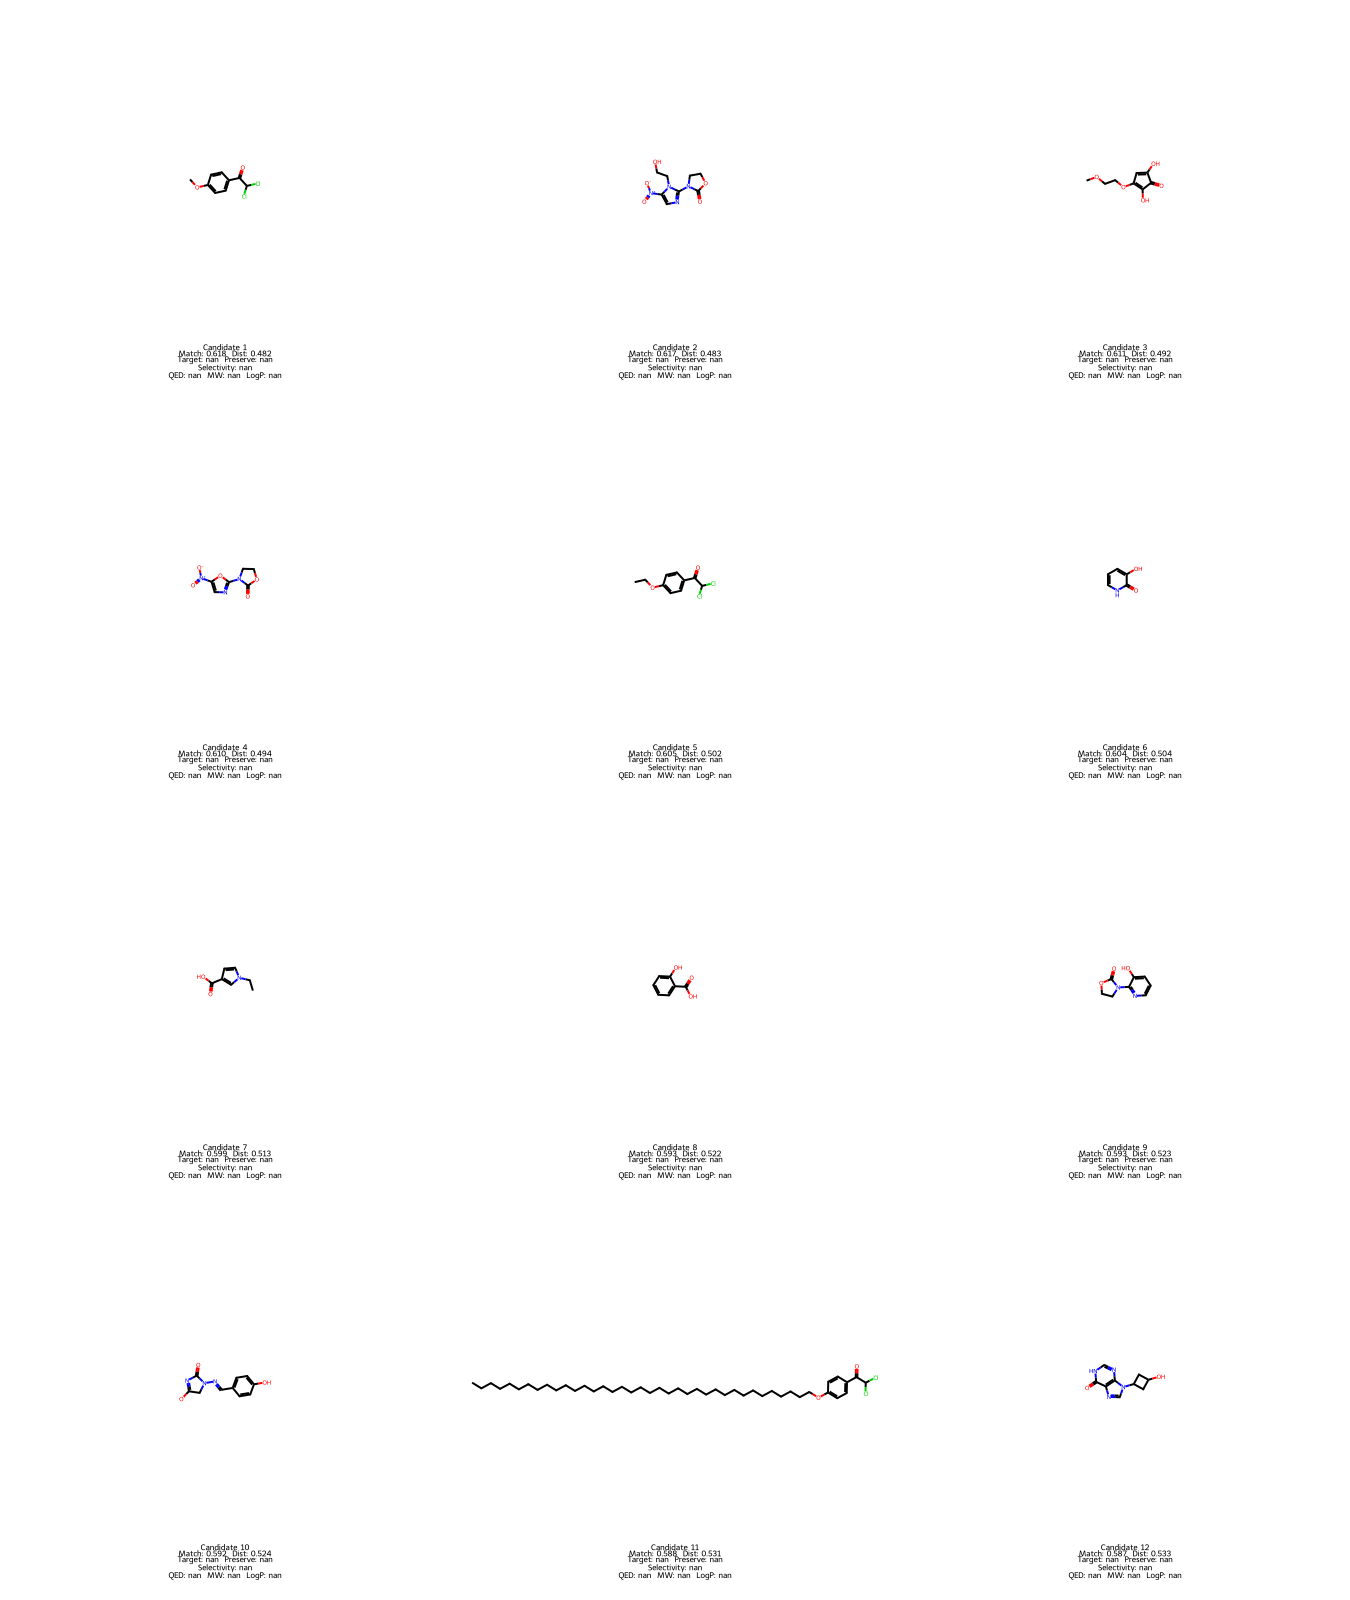

In [42]:
# ============================================================
# 32. Visualize structures from conditional generation
# ============================================================
#
# Display the top molecules generated specifically for the
# requested microbiome perturbation profile.
#
# Properties shown:
#
#   ProfileMatch
#   ProfileDistance
#   TargetPerturbation
#   Preservation
#   Selectivity
#   QED
#   MW
#   LogP
#
# ============================================================

from rdkit import Chem
from rdkit.Chem import Draw
import numpy as np


# ------------------------------------------------------------
# Number of structures to display
# ------------------------------------------------------------

N_STRUCTURES = min(
    12,
    len(target_generated_df)
)


if N_STRUCTURES == 0:

    raise RuntimeError(
        "target_generated_df is empty. "
        "Run Cell 30 first."
    )


# ------------------------------------------------------------
# Select best target-conditioned candidates
# ------------------------------------------------------------

top_candidates = (
    target_generated_df
    .sort_values(
        [
            "ProfileDistance",
            "ProfileMatch"
        ],
        ascending=[
            True,
            False
        ]
    )
    .head(
        N_STRUCTURES
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Convert SMILES to RDKit molecules
# ------------------------------------------------------------

molecules = []
legends = []


for i, row in top_candidates.iterrows():

    smiles = row[
        "SMILES"
    ]

    mol = Chem.MolFromSmiles(
        smiles
    )

    if mol is None:

        continue


    molecules.append(
        mol
    )


    # --------------------------------------------------------
    # Safely retrieve properties
    # --------------------------------------------------------

    profile_match = row.get(
        "ProfileMatch",
        np.nan
    )

    profile_distance = row.get(
        "ProfileDistance",
        np.nan
    )

    target_perturbation = row.get(
        "TargetPerturbation",
        np.nan
    )

    preservation = row.get(
        "Preservation",
        np.nan
    )

    selectivity = row.get(
        "Selectivity",
        np.nan
    )

    qed = row.get(
        "QED",
        np.nan
    )

    mw = row.get(
        "MW",
        np.nan
    )

    logp = row.get(
        "LogP",
        np.nan
    )


    # --------------------------------------------------------
    # Structure legend
    # --------------------------------------------------------

    legend = (
        f"Candidate {i + 1}\n"
        f"Match: {profile_match:.3f}  "
        f"Dist: {profile_distance:.3f}\n"
        f"Target: {target_perturbation:.3f}  "
        f"Preserve: {preservation:.3f}\n"
        f"Selectivity: {selectivity:.3f}\n"
        f"QED: {qed:.3f}  "
        f"MW: {mw:.1f}  "
        f"LogP: {logp:.2f}"
    )

    legends.append(
        legend
    )


# ============================================================
# Draw structure grid
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "TOP TARGET-CONDITIONED MOLECULES"
)

print(
    "=" * 70
)

print(
    f"Displaying {len(molecules)} candidates."
)


img = Draw.MolsToGridImage(
    molecules,
    molsPerRow=3,
    subImgSize=(450, 400),
    legends=legends,
    useSVG=False
)


display(
    img
)

## 14. Interpretation and guardrails

The resulting library is a computational prioritization set.

The surrogate estimates **screen-derived bacterial perturbation patterns** from molecular structure. It does not model intestinal exposure, pharmacokinetics, host effects, ecological recovery, dose dependence, resistance, or clinical outcomes.

For a biologically meaningful optimization, replace the empirical target/preservation quartiles with a prespecified strain panel or functional microbiome grouping and validate top generated compounds against held-out compounds and, ideally, external experimental data.

A useful next extension is to add uncertainty to the surrogate (for example, an ensemble of independently trained Extra Trees models) and penalize candidates whose predicted objective is high but whose surrogate disagreement is also high.